# Tarea 2 - Taller de Deep Learning

**Fecha de entrega: 16/11/2025**  
**Puntaje máximo: 15**

## Introducción

El objetivo de esta tarea es evaluar su capacidad para aplicar modelos de redes neuronales recurrentes (RNN/LSTM/GRU) en un problema de clasificación de secuencias. En particular, vamos a evaluar la performance de sus modelos en la clasificación de ritmos cardíacos usando datos de electrocardiograma (ECG).

**Dataset**

El dataset a ser utilizado es el [Heartbeat Dataset](https://www.kaggle.com/datasets/shayanfazeli/heartbeat). Este dataset contiene señales de ECG segmentadas, donde cada segmento corresponde a un latido del corazón. Cada segmento ya está preprocesado y categorizado en una de las siguientes clases:

- **N**: Normal (0)
- **S**: Arritmia supraventricular (1)
- **V**: Arritmia ventricular (2)
- **F**: Latido fusionado (3)
- **Q**: Latido desconocido (4)

Los archivos del dataset que deben utilizar son:

- **mitbih_train.csv**: Datos de entrenamiento.
- **mitbih_test.csv**: Datos de prueba.

**Tarea**

Tienen total libertad sobre cómo implementar y resolver el problema, así como las técnicas y herramientas que quieran usar. Se recomienda el uso de Google Colab para simplificar el acceso a recursos de GPU, aunque pueden trabajar en sus propias máquinas si lo prefieren. La entrega debe realizarse en formato .ipynb (Jupyter Notebook) **con las celdas ya ejecutadas**.

**Restricciones**

- No se permite utilizar modelos pre-entrenados; cada modelo debe ser implementado desde cero.
- Deben utilizar al menos un modelo basado en RNN (por ejemplo, LSTM o GRU).
- Es necesario realizar un **análisis exploratorio de los datos**, que incluya una descripción de las señales ECG, el balanceo de clases y cualquier limpieza o transformación necesaria de los datos.
- Las decisiones sobre el preprocesamiento de las señales (como normalización, segmentación, etc.) deben estar fundamentadas en una exploración inicial del dataset y explicadas en el notebook.

**Reporte**

Se requiere que reporten las siguientes métricas: accuracy, precision, recall y F1-score para la evaluación del modelo. Además, se espera ver una evolución clara del modelo durante el entrenamiento, que incluya logs y gráficas de las métricas tanto para los datos de entrenamiento como de validación.

**Evidencia de Experimentos**

Deben proporcionar evidencia de la ejecución de experimentos usando [Weights & Biases (wandb)](https://wandb.ai/). Esto incluye:

- Registros detallados de los experimentos.
- Gráficas y logs de entrenamiento.
- Comparaciones entre diferentes configuraciones de modelos.

In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, random_split

from torchinfo import summary

import pandas as pd
import numpy as np

import os
import sys
import tarfile
import urllib.request
import re
from pathlib import Path
from collections import Counter
from itertools import chain


# Datasets 

In [2]:
# pip install kagglehub

In [3]:
os.getcwd()

'c:\\Users\\Matías\\Desktop\\Rodrigo\\Repos\\ORT-AI\\Deep Learning\\Taller de DL\\Tareas\\Tarea 2'

In [4]:
# import kagglehub
# import shutil

# # Descargar dataset
# path = kagglehub.dataset_download("shayanfazeli/heartbeat")

# # Crear carpeta "data" si no existe
# os.makedirs("data", exist_ok=True)

# # Nuevo destino
# dest = os.path.join("data", os.path.basename(path))

# # Mover carpeta descargada a "data"
# shutil.move(path, dest)

# print("Dataset guardado en:", dest)


In [5]:
train_data = pd.read_csv('data/mitbih_train.csv', header=None)
test_data = pd.read_csv('data/mitbih_test.csv', header=None)

In [6]:
train_data.head()

,0,1,2,3,4,5,6,7,8,9,...,178,179,180,181,182,183,184,185,186,187
0,0.977941,0.926471,0.681373,0.245098,0.154412,0.191176,0.151961,0.085784,0.058824,0.049020,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,0.960114,0.863248,0.461538,0.196581,0.094017,0.125356,0.099715,0.088319,0.074074,0.082621,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,1.000000,0.659459,0.186486,0.070270,0.070270,0.059459,0.056757,0.043243,0.054054,0.045946,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,0.925414,0.665746,0.541436,0.276243,0.196133,0.077348,0.071823,0.060773,0.066298,0.058011,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,0.967136,1.000000,0.830986,0.586854,0.356808,0.248826,0.145540,0.089202,0.117371,0.150235,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [7]:
test_data.head()

,0,1,2,3,4,5,6,7,8,9,...,178,179,180,181,182,183,184,185,186,187
0,1.000000,0.758264,0.111570,0.000000,0.080579,0.078512,0.066116,0.049587,0.047521,0.035124,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,0.908425,0.783883,0.531136,0.362637,0.366300,0.344322,0.333333,0.307692,0.296703,0.300366,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,0.730088,0.212389,0.000000,0.119469,0.101770,0.101770,0.110619,0.123894,0.115044,0.132743,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,1.000000,0.910417,0.681250,0.472917,0.229167,0.068750,0.000000,0.004167,0.014583,0.054167,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,0.570470,0.399329,0.238255,0.147651,0.000000,0.003356,0.040268,0.080537,0.070470,0.090604,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [8]:
train_data.rename(columns={187: 'class'}, inplace=True)

id_to_label = {
    0: "Normal",
    1: "Artial Premature",
    2: "Premature ventricular contraction",
    3: "Fusion of ventricular and normal",
    4: "Fusion of paced and normal"
}
train_data['label'] = train_data.iloc[:, -1].map(id_to_label)
print(train_data.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 87554 entries, 0 to 87553
Columns: 189 entries, 0 to label
dtypes: float64(188), object(1)
memory usage: 126.2+ MB
None


In [9]:
test_data.rename(columns={187: 'class'}, inplace=True)

id_to_label = {
    0: "Normal",
    1: "Artial Premature",
    2: "Premature ventricular contraction",
    3: "Fusion of ventricular and normal",
    4: "Fusion of paced and normal"
}
test_data['label'] = test_data.iloc[:, -1].map(id_to_label)
print(test_data.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 21892 entries, 0 to 21891
Columns: 189 entries, 0 to label
dtypes: float64(188), object(1)
memory usage: 31.6+ MB
None


In [10]:
test_data.head()

,0,1,2,3,4,5,6,7,8,9,...,179,180,181,182,183,184,185,186,class,label
0,1.000000,0.758264,0.111570,0.000000,0.080579,0.078512,0.066116,0.049587,0.047521,0.035124,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,Normal
1,0.908425,0.783883,0.531136,0.362637,0.366300,0.344322,0.333333,0.307692,0.296703,0.300366,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,Normal
2,0.730088,0.212389,0.000000,0.119469,0.101770,0.101770,0.110619,0.123894,0.115044,0.132743,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,Normal
3,1.000000,0.910417,0.681250,0.472917,0.229167,0.068750,0.000000,0.004167,0.014583,0.054167,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,Normal
4,0.570470,0.399329,0.238255,0.147651,0.000000,0.003356,0.040268,0.080537,0.070470,0.090604,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,Normal


# EDA

## Distribución de clases
- Los datos están desbalanceados: el 82.8% de los datos son clasificados normales. Hay clases con muy poca representación (2.5% y 0.7%) que requiere tratamiento para lograr un mejore entretamiento.

In [11]:
import nbformat
print(nbformat.__version__)  # debe ser >= 4.2

5.10.4


In [ ]:
import plotly.express as px

# Crear el conteo y reset index con nombres claros
class_counts = train_data['label'].value_counts().reset_index()
class_counts.columns = ['Class', 'Count']  # Renombrar columnas explícitamente

# Calcular porcentaje y formatear como label
total = class_counts['Count'].sum()
class_counts['Percent'] = class_counts['Count'] / total * 100
class_counts['Label'] = class_counts['Percent'].map(lambda x: f'{x:.1f}%')

fig = px.bar(
    class_counts,
    x='Class',
    y='Count',
    color='Class', 
    title='Numero de registros por clase',
    color_discrete_sequence=px.colors.qualitative.Safe,  # Paleta de colores distinta por clase
    text='Label'  # Usar la columna de porcentaje como data label
)

fig.update_traces(
    textposition='outside',  # Ubica el label fuera (arriba) del extremo de la barra
    textfont_size=14,
    texttemplate='%{text}',  # Solo mostrar el texto (el porcentaje)
    insidetextanchor='middle'
)

fig.update_layout(
    uniformtext_minsize=12,  # Asegura tamaño uniforme
    uniformtext_mode='hide',
    xaxis_title='Clase',
    yaxis_title='Count',
    height=600  # <-- Aumenta la altura del gráfico para que no se corte
)

fig.show()

## ECG por clase
- El objetivo de este gráfico es muestrear para cada clase 10 registros y ver cómo es el electrocardiograma por clase.
- Se observa que la clase minoritaria `Fusion of ventricular and normal` son más cortas en tiempo. 
- En esta muestra se aprecia comportamientos similares para cada clase.
- Si bien una muestra de 50 (10 por clase) de 4000 no es muy representativo, se observa que estos 50 registros "no llegan" a la secuencia de 180. Dado que terminan en 0 para completar el largo de la secuencia. 
- El largo de la secuencia será definitivamente uno de los hiperparámetros que se utilizará a la hora de entrenar el modelo.

In [13]:
# Seleccionar columnas de tiempo
value_columns = [col for col in train_data.columns if col not in ['class', 'label']]

num_samples = 10
dfs = []
for class_name in train_data['label'].unique():
    samples = train_data[train_data['label'] == class_name].sample(n=num_samples, random_state=42)
    samples = samples[value_columns].reset_index(drop=True)
    samples['Muestra'] = samples.index  # id de muestra correcto por fila
    df_long = samples.melt(id_vars='Muestra', var_name='Tiempo', value_name='Valor')
    df_long['Clase'] = class_name
    dfs.append(df_long)

plot_df = pd.concat(dfs, ignore_index=True)

# Asegurar tiempo numérico y ordenado
try:
    plot_df['Tiempo'] = plot_df['Tiempo'].astype(float)
except Exception:
    pass
plot_df = plot_df.sort_values(['Clase', 'Muestra', 'Tiempo'])

fig = px.line(
    plot_df,
    x='Tiempo',
    y='Valor',
    color='Muestra',
    facet_row='Clase',
    facet_row_spacing=0.07,
    line_group='Muestra',
    height=300 * len(train_data['label'].unique()),
    title="10 muestras aleatorias de cada clase",
)

fig.update_traces(opacity=0.5, showlegend=False)
fig.update_yaxes(title_text='Valor')
fig.update_xaxes(title_text='Tiempo', matches='x')
fig.update_layout(showlegend=False)
fig.for_each_annotation(lambda a: a.update(text=a.text.split("=")[-1]))
fig.show()

## Amplitud de ECG por clase

- El objetivo del siguiente análisis es observar cuál es la amplitud (pico a pico) de los latidos por clase.
- Todas las muestras de la segunda clase minoritaria `Fusion of paced and normal` tienen una amplitud de 1, es decir, todas las ECG van de 0 a 1.
- Para la clase minoritaria `Fusion of ventricular and normal`, muchas observaciones tienen una amplitud de 1 o cercano a este valor.
- Para la clase `Premature ventricular contraction` se observa una distribución más uniforme entre 0.6 y 1 en relación a las otras clases.
- Al final no se tomó una deción de tratamiento de los datos antes del entrenamiento con este análisis.

In [14]:
def analyze_ecg_amplitude_by_class(
    df,
    label_col: str = 'label',
    value_columns: list[str] | None = None,
    plot: bool = True,
    return_sample_metrics: bool = False,
):
    """
    Analiza la amplitud (pico-a-pico) de latidos ECG por clase.

    - Calcula por muestra: mínimo, máximo y amplitud pico-a-pico (max - min)
    - Agrega por clase: count, mean, std, median, p25, p75, min, max
    - Opcionalmente grafica la distribución por clase (violin y box)

    Args:
        df: DataFrame con columnas de señal (tiempo) y columna de etiqueta.
        label_col: Nombre de la columna con la clase (por defecto 'label').
        value_columns: Lista de columnas de tiempo. Si es None, se infiere
            como todas las columnas excepto {label_col, 'class'}.
        plot: Si True, muestra gráficos de distribución por clase.
        return_sample_metrics: Si True, también devuelve métricas por muestra.

    Returns:
        summary_df si return_sample_metrics == False
        (summary_df, sample_metrics_df) si return_sample_metrics == True
    """
    # Inferir columnas de señal si no se especifican
    if value_columns is None:
        excluded = {label_col, 'class'}
        value_columns = [c for c in df.columns if c not in excluded]

    # Asegurar datos numéricos y calcular métricas por muestra
    signal_matrix = df[value_columns].to_numpy(dtype=float)
    per_sample_min = signal_matrix.min(axis=1)
    per_sample_max = signal_matrix.max(axis=1)
    per_sample_ptp = per_sample_max - per_sample_min  # pico-a-pico

    sample_metrics_df = pd.DataFrame(
        {
            'min_amplitude': per_sample_min,
            'max_amplitude': per_sample_max,
            'peak_to_peak': per_sample_ptp,
            label_col: df[label_col].to_numpy(),
        }
    )

    # Agregación por clase
    def p25(series: pd.Series) -> float:
        return float(np.percentile(series, 25))

    def p75(series: pd.Series) -> float:
        return float(np.percentile(series, 75))

    summary_df = (
        sample_metrics_df.groupby(label_col)['peak_to_peak']
        .agg(
            count='count',
            mean='mean',
            std='std',
            median='median',
            p25=p25,
            p75=p75,
            min='min',
            max='max',
        )
        .reset_index()
        .sort_values(label_col)
    )

    # Gráficos opcionales, con distinción de colores por clase
    if plot:
        # Construir una paleta de colores distinta por cada clase
        unique_classes = sample_metrics_df[label_col].unique()
        color_map = px.colors.qualitative.Plotly  # O puede usarse otra paleta si hay más clases
        color_discrete_map = {
            clase: color_map[i % len(color_map)] for i, clase in enumerate(sorted(unique_classes))
        }

        violin_fig = px.violin(
            sample_metrics_df,
            x=label_col,
            y='peak_to_peak',
            box=True,
            points='outliers',
            labels={label_col: 'Clase', 'peak_to_peak': 'Amplitud pico-a-pico'},
            title='Distribución de amplitud pico-a-pico por clase',
            color=label_col,  # Esto asigna color por clase
            color_discrete_map=color_discrete_map  # Mapea clase a color de la paleta
        )
        violin_fig.show()

    return (summary_df, sample_metrics_df) if return_sample_metrics else summary_df


In [15]:
train_data["label"].unique()

array(['Normal', 'Artial Premature', 'Premature ventricular contraction',
       'Fusion of ventricular and normal', 'Fusion of paced and normal'],
      dtype=object)

In [16]:
summary = analyze_ecg_amplitude_by_class(train_data, label_col='label', plot=True)

## Duración de ECG por clase
- Se observó que existe casos en donde la secuencia se corta pero se popula con 0 para completar con el largo de la secuencia total (180).
- Para calcular la duración real de cada registro, se asume que si hay cinco ceros consecutivos, entonces se debe marcar antes de ese primer cero como fin de la secuencia.
- Efectivamente se observa diferencia en la duración del tiempo de ECG por clase.

In [19]:
# Duración = índice (1-based) de la última columna con valor > zero_tol; 0 si no hay valores > zero_tol
def calcular_duracion_por_ultimo_no_cero(row, zero_tol: float = 0.0):
    arr = row.values.astype(float)
    nz_idx = np.where(arr > zero_tol)[0]
    return int(nz_idx[-1] + 1) if nz_idx.size else 0

# Determinar columnas de señal si no existen previamente
try:
    signal_cols
except NameError:
    signal_cols = [c for c in train_data.columns if c not in ['class', 'label']]

# Aplicar lógica y escribir la duración
train_data['duracion_no_ceros'] = train_data[signal_cols].apply(
    calcular_duracion_por_ultimo_no_cero, axis=1
)



In [20]:
# Ajusta la opción de pandas para mostrar todas las columnas
pd.set_option('display.max_columns', None)


train_data.sort_values(by='duracion_no_ceros').head()

,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20,21,22,23,24,25,26,27,28,29,30,31,32,33,34,35,36,37,38,39,40,41,42,43,44,45,46,47,48,49,50,51,52,53,54,55,56,57,58,59,60,61,62,63,64,65,66,67,68,69,70,71,72,73,74,75,76,77,78,79,80,81,82,83,84,85,86,87,88,89,90,91,92,93,94,95,96,97,98,99,100,101,102,103,104,105,106,107,108,109,110,111,112,113,114,115,116,117,118,119,120,121,122,123,124,125,126,127,128,129,130,131,132,133,134,135,136,137,138,139,140,141,142,143,144,145,146,147,148,149,150,151,152,153,154,155,156,157,158,159,160,161,162,163,164,165,166,167,168,169,170,171,172,173,174,175,176,177,178,179,180,181,182,183,184,185,186,class,label,duracion_no_ceros
44608,1.0,0.919048,0.811905,0.473810,0.295238,0.211905,0.180952,0.135714,0.142857,0.121429,0.000000,0.128571,0.073810,0.078571,0.097619,0.090476,0.140476,0.000000,0.000000,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,Normal,17
42566,1.0,0.988372,0.738372,0.398256,0.133721,0.101744,0.084302,0.127907,0.058140,0.040698,0.023256,0.052326,0.000000,0.017442,0.040698,0.078488,0.052326,0.063953,0.000000,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,Normal,18
13028,0.0,0.050505,0.333333,0.464646,0.777778,0.878788,0.868687,0.878788,0.868687,0.888889,0.919192,0.868687,0.878788,0.929293,0.919192,0.888889,0.989899,1.000000,0.000000,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,Normal,18
18035,1.0,0.393939,0.056277,0.129870,0.095238,0.086580,0.077922,0.103896,0.086580,0.095238,0.095238,0.086580,0.082251,0.099567,0.095238,0.116883,0.099567,0.069264,0.073593,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0

In [21]:
import plotly.express as px

fig = px.histogram(
    train_data, 
    x="duracion_no_ceros", 
    color="label", 
    barmode="overlay", 
    nbins=40,
    title="Histograma de duración ECG por clase",
    labels={"duracion_no_ceros": "Duración", "label": "Clases"}
)
fig.show()


# Pre procesamiento de datos
## Balanceo de datos: Submuestra de la clase mayoritaria

- Dado que la clase mayoritaria representa el 82.8% de los registros, se toma la decisión de submuestrear esta clase para que baje ese porcentaje.
- Luego de la submuestra, la clase `Normal` tiene 70% del total de registros. Este porcentaje irá reduciendose cuando se tomen medidas adicionales para mejorar el balance de los datos.

In [22]:
def undersample_majority(df, label_col='label', ratio=None, target=None, random_state=42):
    """
    - Si ratio se da: reduce la mayoritaria a floor(minority_count * ratio)
    - Si target=int: reduce la mayoritaria a 'target'
    - Por defecto: balancea a la menor (target = minority_count)
    """
    counts = df[label_col].value_counts()
    if counts.empty or len(counts) == 1:
        return df.copy()

    majority_class = counts.idxmax()
    minority_count = counts.drop(majority_class).min()

    if ratio is not None:
        target_count = int(minority_count * ratio)
    elif isinstance(target, int):
        target_count = min(target, counts[majority_class])
    else:
        target_count = minority_count  # balance 1:1

    majority_df = df[df[label_col] == majority_class].sample(
        n=target_count, random_state=random_state
    )
    rest_df = df[df[label_col] != majority_class]

    out = pd.concat([rest_df, majority_df], axis=0)
    out = out.sample(frac=1, random_state=random_state).reset_index(drop=True)
    return out


In [23]:
train_data_us = undersample_majority(train_data, label_col='label', target=35000)

# Verificación
print("Antes de la sub-muestra:\n", train_data['label'].value_counts(), "\n")
print("Después de la sub-muestra:\n", train_data_us['label'].value_counts())

Antes de la sub-muestra:
 label
Normal                               72471
Fusion of paced and normal            6431
Premature ventricular contraction     5788
Artial Premature                      2223
Fusion of ventricular and normal       641
Name: count, dtype: int64 

Después de la sub-muestra:
 label
Normal                               35000
Fusion of paced and normal            6431
Premature ventricular contraction     5788
Artial Premature                      2223
Fusion of ventricular and normal       641
Name: count, dtype: int64


## Oversampling de las clases minoritarias

- Para las clases minoritarias se realizará un sobremuestreo de los registros.
- Se decide llegar por lo menos al 10% respecto a la clase `Normal` para cada una de las clases minoritarias.
- Las clases afectadas son las últimas dos (`Artial Premature` y `Fusion of ventricular and normal`).
- De este modo, se preservan en cierta medida el desbalanceo de los datos pero, al mismo tiempo, se mejora la calidad para el entrenamiento.

In [24]:
def oversample_minorities(
    df: pd.DataFrame,
    label_col: str = 'label',
    strategy: str = 'to_majority',  # 'to_majority' | 'ratio' | 'fixed'
    ratio: float | None = None,     # ej. 0.8 -> 80% del tamaño de la mayoritaria
    target: int | None = None,      # ej. 12000 -> tamaño fijo por clase
    random_state: int = 42,
) -> pd.DataFrame:
    """
    Oversamplea solo las clases minoritarias.
    - strategy='to_majority': sube todas las clases al tamaño de la mayoritaria (1:1).
    - strategy='ratio': sube todas las clases a int(majority_count * ratio).
    - strategy='fixed': sube todas las clases a 'target'.
    """
    counts = df[label_col].value_counts()
    if counts.empty or len(counts) == 1:
        return df.copy()

    majority_count = counts.max()

    if strategy == 'to_majority':
        target_count = majority_count
    elif strategy == 'ratio':
        if ratio is None or ratio <= 0:
            raise ValueError("Debes pasar un 'ratio' > 0 para strategy='ratio'.")
        target_count = int(majority_count * ratio)
    elif strategy == 'fixed':
        if target is None or target <= 0:
            raise ValueError("Debes pasar 'target' > 0 para strategy='fixed'.")
        target_count = target
    else:
        raise ValueError("strategy debe ser 'to_majority', 'ratio' o 'fixed'.")

    parts = []
    for cls, cnt in counts.items():
        cls_df = df[df[label_col] == cls]
        if cnt >= target_count:
            parts.append(cls_df)
        else:
            # tomar todo lo original + muestrear con reposición lo faltante
            needed = target_count - cnt
            sampled = cls_df.sample(n=needed, replace=True, random_state=random_state)
            parts.append(pd.concat([cls_df, sampled], axis=0))

    out = pd.concat(parts, axis=0).sample(frac=1, random_state=random_state).reset_index(drop=True)
    return out



In [25]:
# Llevar todas las clases al 80% del tamaño de la mayoritaria
train_data_us_os = oversample_minorities(train_data_us, label_col='label', strategy='ratio', ratio=0.1)

# Verificación
print("Antes de over y under sampling:\n", train_data['label'].value_counts(), "\n")
print("Después de over y under sampling:\n", train_data_us_os['label'].value_counts())

Antes de over y under sampling:
 label
Normal                               72471
Fusion of paced and normal            6431
Premature ventricular contraction     5788
Artial Premature                      2223
Fusion of ventricular and normal       641
Name: count, dtype: int64 

Después de over y under sampling:
 label
Normal                               35000
Fusion of paced and normal            6431
Premature ventricular contraction     5788
Artial Premature                      3500
Fusion of ventricular and normal      3500
Name: count, dtype: int64


## Data Augmentation para clases minoritarias

Se realiza data augmentation sobre las clases minoritarias para tratar al problema de desbalance. Los métodos utilizados en este caso fueron:

* **Jitter:** añade ruido gaussiano bajo (σ≈0.01–0.05 del rango).

* **Escalado de amplitud:** multiplica por 0.9–1.1. (skippear casos = 1)

* **Time shift:** desplaza pocos samples (con padding).

* **Permutación**: de 3–6 sub-segmentos cortos (muy leve).

In [26]:
def jitter_signal(x: np.ndarray, sigma: float = 0.02, rng: np.random.Generator | None = None) -> np.ndarray:
    """Añade ruido gaussiano con desv. std relativa al std de la señal (suave)."""
    rng = np.random.default_rng(rng)
    x = np.asarray(x, dtype=float)
    noise = rng.normal(0.0, sigma * (np.std(x) + 1e-8), size=x.shape)
    return (x + noise).astype(x.dtype)


def scale_amplitude(x: np.ndarray, scale_range: tuple[float, float] = (0.9, 1.1), rng: np.random.Generator | None = None) -> np.ndarray:
    """Escala amplitud por un factor uniforme dentro de scale_range."""
    rng = np.random.default_rng(rng)
    x = np.asarray(x, dtype=float)
    factor = rng.uniform(scale_range[0], scale_range[1])
    return (x * factor).astype(x.dtype)


def time_shift_signal(
    x: np.ndarray,
    max_shift: int = 5,
    pad_mode: str = 'reflect',  # 'reflect' | 'constant'
    constant_value: float = 0.0,
    rng: np.random.Generator | None = None,
) -> np.ndarray:
    """Desplaza la señal en el tiempo (no circular)."""
    rng = np.random.default_rng(rng)
    x = np.asarray(x, dtype=float)
    n = len(x)
    if max_shift <= 0:
        return x
    shift = int(rng.integers(-max_shift, max_shift + 1))
    if shift == 0:
        return x

    if shift > 0:  # desplazar a la derecha => rellenar al inicio
        pad = x[:shift][::-1] if pad_mode == 'reflect' else np.full(shift, constant_value)
        y = np.concatenate([pad, x[:-shift]])
    else:  # desplazar a la izquierda => rellenar al final
        s = abs(shift)
        pad = x[-s:][::-1] if pad_mode == 'reflect' else np.full(s, constant_value)
        y = np.concatenate([x[s:], pad])
    return y.astype(x.dtype)


def permute_subsegments(
    x: np.ndarray,
    k_range: tuple[int, int] = (3, 6),
    min_len: int = 10,
    rng: np.random.Generator | None = None,
) -> np.ndarray:
    """Corta la señal en k trozos contiguos (k en [k_min,k_max]) y los reordena."""
    rng = np.random.default_rng(rng)
    x = np.asarray(x, dtype=float)
    n = len(x)
    k = int(rng.integers(k_range[0], k_range[1] + 1))
    # elegir k-1 cortes evitando segmentos demasiado cortos
    if n < (k * min_len):
        return x  # no hay espacio suficiente
    valid_cuts = np.arange(min_len, n - min_len)
    cuts = np.sort(rng.choice(valid_cuts, size=k - 1, replace=False))
    idxs = np.concatenate([[0], cuts, [n]])
    segs = [x[idxs[i]:idxs[i + 1]] for i in range(len(idxs) - 1) if (idxs[i + 1] - idxs[i]) >= min_len]
    if len(segs) <= 1:
        return x
    order = rng.permutation(len(segs))
    return np.concatenate([segs[i] for i in order]).astype(x.dtype)


# --------- Wrapper para aplicar a clases minoritarias en un DataFrame ---------

def augment_minority_classes(
    df: pd.DataFrame,
    label_col: str = 'label',
    value_columns: list[str] | None = None,
    strategy: str = 'to_majority',  # 'to_majority' | 'ratio' | 'fixed'
    ratio: float | None = None,
    target: int | None = None,
    transforms: list | None = None,
    random_state: int = 42,
) -> pd.DataFrame:
    """
    Genera nuevos ejemplos de las clases minoritarias aplicando aleatoriamente una
    de las transformaciones definidas arriba a filas existentes (con reposición).

    - strategy='to_majority': sube minoritarias al tamaño de la mayoritaria.
    - strategy='ratio': sube minoritarias a int(majority_count * ratio).
    - strategy='fixed': sube minoritarias a 'target'.
    """
    rng = np.random.default_rng(random_state)

    if value_columns is None:
        excluded = {label_col, 'class'}
        value_columns = [c for c in df.columns if c not in excluded]

    counts = df[label_col].value_counts()
    if counts.empty or len(counts) == 1:
        return df.copy()

    majority_count = counts.max()
    if strategy == 'to_majority':
        target_count = majority_count
    elif strategy == 'ratio':
        if ratio is None or ratio <= 0:
            raise ValueError("Debes pasar ratio>0 para strategy='ratio'.")
        target_count = int(majority_count * ratio)
    elif strategy == 'fixed':
        if target is None or target <= 0:
            raise ValueError("Debes pasar target>0 para strategy='fixed'.")
        target_count = target
    else:
        raise ValueError("strategy debe ser 'to_majority' | 'ratio' | 'fixed'.")

    if not transforms:
        transforms = [
            lambda x: jitter_signal(x, sigma=0.02, rng=rng),
            lambda x: scale_amplitude(x, scale_range=(0.9, 1.1), rng=rng),
            lambda x: time_shift_signal(x, max_shift=5, pad_mode='reflect', rng=rng),
            lambda x: permute_subsegments(x, k_range=(3, 6), min_len=10, rng=rng),
        ]

    parts = [df]

    for cls, cnt in counts.items():
        if cnt >= target_count:
            continue  # no es minoritaria con respecto al objetivo
        cls_df = df[df[label_col] == cls]
        needed = target_count - cnt
        # muestrear índices base con reposición
        base_idx = cls_df.sample(n=needed, replace=True, random_state=int(rng.integers(0, 1e9))).index
        augmented_rows = []
        for idx in base_idx:
            row = df.loc[idx]
            sig = row[value_columns].to_numpy(dtype=float)
            # elegir una transformación al azar
            t = transforms[int(rng.integers(0, len(transforms)))]
            sig_aug = t(sig)
            new_row = row.copy()
            new_row[value_columns] = sig_aug
            augmented_rows.append(new_row)
        if augmented_rows:
            parts.append(pd.DataFrame(augmented_rows))

    out = pd.concat(parts, axis=0).sample(frac=1.0, random_state=int(rng.integers(0, 1e9))).reset_index(drop=True)
    return out


In [ ]:
train_data_us_os_da = augment_minority_classes(train_data_us_os, label_col='label', strategy='ratio', ratio=0.05)

In [ ]:
def verify_class_balance(df_before, df_after, label_col='label'):
    before = df_before[label_col].value_counts().sort_index()
    after = df_after[label_col].value_counts().sort_index()
    comp = pd.DataFrame({
        'before': before,
        'after': after,
        'delta': (after - before)
    })
    comp['before_pct'] = (comp['before'] / comp['before'].sum() * 100).round(1)
    comp['after_pct']  = (comp['after']  / comp['after'].sum()  * 100).round(1)
    print(comp.fillna(0).astype({'before':'int64','after':'int64','delta':'int64'}))

verify_class_balance(train_data, train_data_us_os_da)   # oversampling / augmentación

                                   before  after  delta  before_pct  after_pct
label                                                                         
Artial Premature                     2223   3500   1277         2.5        6.5
Fusion of paced and normal           6431   6431      0         7.3       11.9
Fusion of ventricular and normal      641   3500   2859         0.7        6.5
Normal                              72471  35000 -37471        82.8       64.6
Premature ventricular contraction    5788   5788      0         6.6       10.7


# Entrenamientos

* Sampler ponderado (WeightedRandomSampler) para batches balanceados.
* Regularización (dropout, weight decay) para evitar overfit por oversampling.
* Class weights (https://discuss.pytorch.org/t/passing-the-weights-to-crossentropyloss-correctly/14731)

In [29]:
# Fijamos la semilla para que los resultados sean reproducibles
SEED = 23

torch.manual_seed(SEED)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

In [30]:
# definimos el dispositivo que vamos a usar
DEVICE = "cpu"  # por defecto, usamos la CPU
if torch.cuda.is_available():
    DEVICE = "cuda"  # si hay GPU, usamos la GPU
elif torch.backends.mps.is_available():
    DEVICE = "mps"  # si no hay GPU, pero hay MPS, usamos MPS
elif torch.xpu.is_available():
    DEVICE = "xpu"  # si no hay GPU, pero hay XPU, usamos XPU

print(f"Usando {DEVICE}")

NUM_WORKERS = 0 # Win y MacOS pueden tener problemas con múltiples workers
if sys.platform == 'linux':
    NUM_WORKERS = 4  # numero de workers para cargar los datos (depende de cada caso)

print(f"Usando {NUM_WORKERS}")

Usando cuda
Usando 0


In [31]:
BATCH_SIZE = 256  # tamaño del batch

## Data Loader

In [32]:
class CardiacLogDataset(Dataset):
    def __init__(self, sequences, labels, transforms=None):
        # Convert to numpy arrays so positional indexing works
        self.sequences = sequences.to_numpy(dtype=float) if hasattr(sequences, "to_numpy") else np.asarray(sequences, dtype=float)
        self.labels = labels.to_numpy(dtype=int) if hasattr(labels, "to_numpy") else np.asarray(labels, dtype=int)
        self.transforms = transforms

    def __len__(self):
        return len(self.sequences)

    def __getitem__(self, idx):
        sequence = torch.tensor(self.sequences[idx], dtype=torch.float)
        label = torch.tensor(self.labels[idx], dtype=torch.long)
        if self.transforms:
            sequence = self.transforms(sequence)
        return sequence, label

In [33]:
%pip install scikit-learn

Note: you may need to restart the kernel to use updated packages.


In [34]:
from sklearn.model_selection import train_test_split

train_labels = train_data_us_os_da['class'] 
train_data = train_data_us_os_da.drop(columns=['class','label','duracion_no_ceros'])

# División de los datos en entrenamiento (train) y validación (val)
train_data, val_data, train_labels, val_labels = train_test_split(
    train_data, 
    train_labels, 
    test_size=0.2, 
    random_state=SEED, 
    stratify=train_labels
)


In [35]:
train_data

,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20,21,22,23,24,25,26,27,28,29,30,31,32,33,34,35,36,37,38,39,40,41,42,43,44,45,46,47,48,49,50,51,52,53,54,55,56,57,58,59,60,61,62,63,64,65,66,67,68,69,70,71,72,73,74,75,76,77,78,79,80,81,82,83,84,85,86,87,88,89,90,91,92,93,94,95,96,97,98,99,100,101,102,103,104,105,106,107,108,109,110,111,112,113,114,115,116,117,118,119,120,121,122,123,124,125,126,127,128,129,130,131,132,133,134,135,136,137,138,139,140,141,142,143,144,145,146,147,148,149,150,151,152,153,154,155,156,157,158,159,160,161,162,163,164,165,166,167,168,169,170,171,172,173,174,175,176,177,178,179,180,181,182,183,184,185,186
576,1.000000,0.798343,0.624309,0.417127,0.306630,0.204420,0.104972,0.069061,0.055249,0.055249,0.063536,0.055249,0.066298,0.055249,0.077348,0.063536,0.058011,0.055249,0.060773,0.044199,0.060773,0.041436,0.055249,0.038674,0.074586,0.063536,0.080110,0.085635,0.127072,0.129834,0.171271,0.190608,0.237569,0.220994,0.248619,0.229282,0.243094,0.215470,0.215470,0.198895,0.198895,0.168508,0.182320,0.160221,0.168508,0.168508,0.176796,0.160221,0.157459,0.157459,0.176796,0.171271,0.179558,0.165746,0.185083,0.162983,0.182320,0.171271,0.182320,0.168508,0.168508,0.162983,0.162983,0.146409,0.171271,0.176796,0.223757,0.223757,0.248619,0.262431,0.287293,0.287293,0.279006,0.240331,0.160221,0.107735,0.118785,0.107735,0.127072,0.121547,0.129834,0.132597,0.146409,0.116022,0.116022,0.143646,0.364641,0.698895,0.950276,0.906077,0.693370,0.450276,0.364641,0.179558,0.088398,0.024862,0.024862,0.011050,0.011050,0.011050,0.000000,0.008287,0.008287,0.000000,0.013812,0.000000,0.022099,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000,0.00000,0.000000,0.000000,0.00000,0.00000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
7304,1.000000,0.590226,0.582707,0.582707,0.578947,0.563910,0.537594,0.466165,0.308271,0.187970,0.000000,0.060150,0.112782,0.120301,0.124060,0.221805,0.195489,0.191729,0.184211,0.218045,0.206767,0.225564,0.218045,0.221805,0.214286,0.214286,0.203008,0.214286,0.195489,0.214286,0.199248,0.221805,0.225564,0.244361,0.244361,0.278196,0.281955,0.312030,0.312030,0.342105,0.342105,0.364662,0.360902,0.375940,0.330827,0.342105,0.319549,0.323308,0.312030,0.330827,0.323308,0.323308,0.296992,0.319549,0.289474,0.285714,0.263158,0.270677,0.248120,0.255639,0.236842,0.259398,0.229323,0.236842,0.218045,0.236842,0.221805,0.236842,0.210526,0.221805,0.191729,0.214286,0.195489,0.218045,0.203008,0.214286,0.203008,0.203008,0.184211,0.214286,0.191729,0.221805,0.195489,0.214286,0.187970,0.199248,0.203008,0.214286,0.187970,0.214286,0.206767,0.221805,0.229323,0.229323,0.210526,0.251880,0.248120,0.327068,0.748120,0.921053,0.571429,0.590226,0.582707,0.597744,0.552632,0.571429,0.526316,0.439850,0.300752,0.142857,0.056391,0.116541,0.071429,0.109023,0.146617,0.191729,0.154135,0.154135,0.157895,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000,0.00000,0.000000,0.000000,0.00000,0.00000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
26819,1.000000,0.701493,0.160448,0.078358,0.134328,0.130597,0.093284,0.070896,0.067164,0.070896,0.067164,0.052239,0.059701,0.078358,0.078358,0.070896,0.078358,0.093284,0.093284,0.082090,0.085821,0.100746,0.089552,0.089552,0.093284,0.108209,0.111940,0.100746,0.111940,0.130597,0.126866,0.115672,0.149254,0.175373,0.186567,0.167910,0.164179,0.16791

In [36]:
test_labels = test_data['class'] 
test_data = test_data.drop(columns=['class','label'])


In [37]:
train_dataset = CardiacLogDataset(train_data, train_labels)
val_dataset   = CardiacLogDataset(val_data,   val_labels)
test_dataset  = CardiacLogDataset(test_data,  test_labels)

In [38]:
def get_data_loaders(batch_size):
    train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True,  num_workers=NUM_WORKERS)
    val_loader   = DataLoader(val_dataset,   batch_size=batch_size, shuffle=False, num_workers=NUM_WORKERS)
    test_loader  = DataLoader(test_dataset,  batch_size=batch_size, shuffle=False, num_workers=NUM_WORKERS)
    return train_loader, val_loader, test_loader


In [39]:
train_loader, val_loader, test_loader = get_data_loaders(BATCH_SIZE)

In [40]:
class_counts = Counter(train_labels)
total = sum(class_counts.values())
class_weights = {cls: total/count for cls, count in class_counts.items()}
class_weights = torch.tensor([class_weights[0], class_weights[1]], dtype=torch.float).to(DEVICE)

print(f"Class Weights: {class_weights}")

Class Weights: tensor([ 1.5491, 15.4911], device='cuda:0')


In [41]:
class_counts.values()

dict_values([28000, 5145, 2800, 4630, 2800])

## Definición de algunos parámetros para el modelo de RNN

In [42]:
CRITERION = nn.CrossEntropyLoss()  # función de pérdida con pesos para cada clase
LR = 0.0005
EPOCHS = 100

In [ ]:
# Constantes
SEQUENCE_LENGTH = 120  
PADDING_VALUE = 0  # Padding value

### Login a Weight and Bias

In [44]:
import wandb

In [45]:
wandb.login(key="371d1ec6f09f8bd9b3f43d38d319dae857ea940f")

wandb: WARNING If you're specifying your api key in code, ensure this code is not shared publicly.
wandb: WARNING Consider setting the WANDB_API_KEY environment variable, or running `wandb login` from the command line.
wandb: Appending key for api.wandb.ai to your netrc file: C:\Users\Matías\_netrc
wandb: Currently logged in as: josefinalin (RoJo) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


True

### Modelo

Se define:
- EarlyStopping
- La función de evaluate()
- La clase CardiacRNNClassifier donde la arquitectura es igual entre los distintos modelos: RNN, LSTM y GRU solo que varía al aplicar cada modelo. Para esto se generó un parámetro llamado `rnn_type`.

In [46]:
class EarlyStopping:
    def __init__(self, patience=5):
        """
        Args:
            patience (int): Cuántas épocas esperar después de la última mejora.
        """
        self.patience = patience
        self.counter = 0
        self.best_score = float("inf")
        self.val_loss_min = float("inf")
        self.early_stop = False

    def __call__(self, val_loss):
        if val_loss > self.best_score:
            self.counter += 1
            if self.counter >= self.patience:
                self.early_stop = True
        else:
            self.best_score = val_loss
            self.counter = 0

In [47]:
def evaluate(model, criterion, data_loader, device):
    """
    Evalúa el modelo en los datos proporcionados y calcula la pérdida promedio.

    Args:
        model (torch.nn.Module): El modelo que se va a evaluar.
        criterion (torch.nn.Module): La función de pérdida que se utilizará para calcular la pérdida.
        data_loader (torch.utils.data.DataLoader): DataLoader que proporciona los datos de evaluación.

    Returns:
        float: La pérdida promedio en el conjunto de datos de evaluación.

    """
    model.eval()  # ponemos el modelo en modo de evaluacion
    total_loss = 0  # acumulador de la perdida
    with torch.no_grad():  # deshabilitamos el calculo de gradientes
        for x, y in data_loader:  # iteramos sobre el dataloader
            x = x.to(device)  # movemos los datos al dispositivo
            y = y.to(device)  # movemos los datos al dispositivo
            output = model(x)  # forward pass
            total_loss += criterion(output, y).item()  # acumulamos la perdida
    return total_loss / len(data_loader)  # retornamos la perdida promedio


In [48]:
import torch
import torch.nn as nn
import torch.nn.functional as F 

class CardiacRNNClassifier(nn.Module):
    def __init__(
        self,
        hidden_dim,
        num_classes=10,
        rnn_type='rnn',
        bidirectional=False,
        input_dim=1,
        seq_len=120,
        dropout=0.0,          
    ):
        super().__init__()
        self.bidirectional = bidirectional
        self.seq_len = seq_len
        self.dropout_p = float(dropout)

        hidden_out = hidden_dim * (2 if bidirectional else 1)

        # RNN
        if rnn_type == 'lstm':
            self.rnn = nn.LSTM(
                input_size=input_dim,
                hidden_size=hidden_dim,
                batch_first=True,
                bidirectional=bidirectional,
            )
        elif rnn_type == 'gru':
            self.rnn = nn.GRU(
                input_size=input_dim,
                hidden_size=hidden_dim,
                batch_first=True,
                bidirectional=bidirectional,
            )
        else:
            self.rnn = nn.RNN(
                input_size=input_dim,
                hidden_size=hidden_dim,
                batch_first=True,
                bidirectional=bidirectional,
            )

        # Dropout entre representación y la capa final
        self.dropout = nn.Dropout(p=self.dropout_p)

        # Capa final para clasificación
        self.fc = nn.Linear(hidden_out, num_classes)
    
    def forward(self, x):
        if x.ndim == 2:
            x = x.unsqueeze(-1)  # (B, T) -> (B, T, 1)
        x = x.float()

        # Truncado/padding a longitud fija self.seq_len
        T = x.size(1)
        if T > self.seq_len:
            x = x[:, :self.seq_len, :]  # truncar a los primeros seq_len pasos
        elif T < self.seq_len:
            pad_t = self.seq_len - T
            x = F.pad(x, (0, 0, 0, pad_t))  # pad en dimensión temporal (derecha)

        out, hidden = self.rnn(x)
        if isinstance(hidden, tuple):  # LSTM
            hidden = hidden[0]         # h_n

        # hidden: (num_layers * num_directions, B, hidden_dim)
        if self.bidirectional:
            x = torch.cat((hidden[-2], hidden[-1]), dim=1)  # (B, hidden_dim*2)
        else:
            x = hidden[-1]                                  # (B, hidden_dim)

        # aplicar dropout antes de la capa fully-connected
        x = self.dropout(x)

        return self.fc(x)


In [49]:
from torchinfo import summary

summary(CardiacRNNClassifier(hidden_dim=256, rnn_type='rnn', bidirectional=False, input_dim=1, seq_len=SEQUENCE_LENGTH),
input_size=(BATCH_SIZE, SEQUENCE_LENGTH),
dtypes=[torch.int32],
)

Layer (type:depth-idx)                   Output Shape              Param #
CardiacRNNClassifier                     [256, 10]                 --
├─RNN: 1-1                               [256, 120, 256]           66,304
├─Dropout: 1-2                           [256, 256]                --
├─Linear: 1-3                            [256, 10]                 2,570
Total params: 68,874
Trainable params: 68,874
Non-trainable params: 0
Total mult-adds (Units.GIGABYTES): 2.04
Input size (MB): 0.12
Forward/backward pass size (MB): 62.94
Params size (MB): 0.28
Estimated Total Size (MB): 63.33

## Entrenamiento con Weight and Bias

Se define la función de entrenamiento con weight and bias en donde consume `config` que se registra todos los hiperparámetros a optimizar. 
Además se loguea las métricas: 
- val_loss, 
- val_precision, 
- val_accuracy, 
- val_recall, 
- val_f1, 
- entre otras.

In [50]:
WANDB_PROJECT = 'Entrega 2 - RNN, LSTM, GRU'

In [51]:
def train_wandb_rnn(config=None):

    import os
    import numpy as np
    import torch
    from sklearn.metrics import precision_recall_fscore_support, accuracy_score

    AVERAGE = "weighted"
    
    def _as_int(x, default=None):
        if x is None:
            return default
        if isinstance(x, (list, tuple)):
            return int(x[0]) if len(x) > 0 else default
        try:
            if isinstance(x, torch.Tensor):
                return int(x.item())
        except Exception:
            pass
        try:
            return int(x)
        except Exception:
            return default

    with wandb.init(config=config):
        config = wandb.config

        # Normalizar y validar rnn_type
        rnn_type = getattr(config, "rnn_type", "rnn").lower()
        assert rnn_type in {"rnn", "lstm", "gru"}, f"rnn_type no soportado: {rnn_type}"

        # Preparar loaders con el batch_size
        batch_size = _as_int(getattr(config, "batch_size", 64), default=64)
        train_loader, val_loader, _ = get_data_loaders(batch_size)

        # Argumentos para el modelo
        model_kwargs = {
            "hidden_dim": _as_int(config.hidden_dim),
            "rnn_type": rnn_type,
            "bidirectional": bool(getattr(config, "bidirectional", False)),
            "input_dim": getattr(config, "input_dim", 1),
            "dropout": float(getattr(config, "dropout", 0.0)),  
        }

        if hasattr(config, "seq_len"):
            model_kwargs["seq_len"] = _as_int(getattr(config, "seq_len", 120), default=120)

        model = CardiacRNNClassifier(**model_kwargs).to(DEVICE)

        # Configurar optimizador con weight decay
        if getattr(config, "optimizer", "adam") == "adam":
            optimizer = optim.Adam(
                model.parameters(),
                lr=float(config.learning_rate),
                weight_decay=float(config.weight_decay)
            )
        else:
            optimizer = optim.SGD(
                model.parameters(),
                lr=float(config.learning_rate),
                momentum=0.9,
                weight_decay=float(config.weight_decay)
            )

        # --- EarlyStopping ---
        do_early_stopping = bool(getattr(config, "do_early_stopping", False))
        patience = _as_int(getattr(config, "patience", 15), default=5)
        early_stopper = EarlyStopping(patience=patience) if do_early_stopping else None

        # Registrar el modelo en wandb
        wandb.watch(model, log="all", log_freq=100)

        # Entrenamiento
        best_val_loss = float("inf")
        best_val_acc = 0.0
        early_stop_epoch = None

        for epoch in range(EPOCHS):
            # ---------- TRAIN ----------
            model.train()
            train_loss = 0.0
            train_correct = 0
            train_total = 0

            train_preds = []
            train_targs = []

            for inputs, targets in train_loader:
                inputs, targets = inputs.to(DEVICE), targets.to(DEVICE)

                optimizer.zero_grad()
                outputs = model(inputs)
                loss = CRITERION(outputs, targets)
                loss.backward()
                optimizer.step()

                train_loss += loss.item()
                _, predicted = outputs.max(1)
                train_total += targets.size(0)
                train_correct += predicted.eq(targets).sum().item()

                train_preds.append(predicted.detach().cpu())
                train_targs.append(targets.detach().cpu())

            train_loss = train_loss / len(train_loader)
            train_acc = 100.0 * train_correct / train_total

            train_preds = torch.cat(train_preds).numpy()
            train_targs = torch.cat(train_targs).numpy()
            train_precision, train_recall, train_f1, _ = precision_recall_fscore_support(
                train_targs, train_preds, average=AVERAGE, zero_division=0
            )
            train_precision *= 100.0
            train_recall *= 100.0
            train_f1 *= 100.0

            # ---------- VALIDATION ----------
            model.eval()
            val_loss = 0.0
            val_correct = 0
            val_total = 0

            val_preds = []
            val_targs = []

            with torch.no_grad():
                for inputs, targets in val_loader:
                    inputs, targets = inputs.to(DEVICE), targets.to(DEVICE)
                    outputs = model(inputs)
                    loss = CRITERION(outputs, targets)

                    val_loss += loss.item()
                    _, predicted = outputs.max(1)
                    val_total += targets.size(0)
                    val_correct += predicted.eq(targets).sum().item()

                    val_preds.append(predicted.detach().cpu())
                    val_targs.append(targets.detach().cpu())

            val_loss = val_loss / len(val_loader)
            val_acc = 100.0 * val_correct / val_total

            val_preds = torch.cat(val_preds).numpy()
            val_targs = torch.cat(val_targs).numpy()
            val_precision, val_recall, val_f1, _ = precision_recall_fscore_support(
                val_targs, val_preds, average=AVERAGE, zero_division=0
            )
            val_precision *= 100.0
            val_recall *= 100.0
            val_f1 *= 100.0

            # Guardar mejor modelo 
            if val_acc > best_val_acc:
                best_val_acc = val_acc
                best_val_loss = val_loss
                name = f"{str(config.rnn_type).lower()}_best_model.pth"
                save_path = os.path.join(wandb.run.dir, name)
                torch.save(model.state_dict(), save_path)

                # wandb.save(name, base_path=wandb.run.dir, policy="now")
                # name = f"{str(config.rnn_type).lower()}_best_model.pth"
                # save_path = os.path.join(wandb.run.dir, name)
                # torch.save(model.state_dict(), save_path)

                
                wandb.save(save_path, base_path=wandb.run.dir, policy="now")
                
            # --- Llamar a EarlyStopping sobre val_loss ---
            if early_stopper is not None:
                early_stopper(val_loss)
                wandb.log({"early_stopping_counter": early_stopper.counter})
                if early_stopper.early_stop:
                    early_stop_epoch = epoch + 1
                    print(f"Early stopping en la época {early_stop_epoch}")
                    # Log para poder verlo luego en Weights & Biases
                    wandb.log({"early_stopped": True, "early_stop_epoch": early_stop_epoch})
                    break

            # Logging normal
            wandb.log({
                "epoch": epoch,
                "train_loss": train_loss,
                "train_acc": train_acc,
                "train_precision": train_precision,
                "train_recall": train_recall,
                "train_f1": train_f1,
                "val_loss": val_loss,
                "val_acc": val_acc,
                "val_precision": val_precision,
                "val_recall": val_recall,
                "val_f1": val_f1,
                "learning_rate": optimizer.param_groups[0]['lr'],
                "rnn_type": rnn_type,
                "seq_len": model_kwargs.get("seq_len"),
            })

            # Print progress
            print(f'Epoch: {epoch+1}/{EPOCHS}')
            print(f'Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.2f}% | '
                  f'Precision: {train_precision:.2f}% Recall: {train_recall:.2f}% F1: {train_f1:.2f}%')
            print(f'Val   Loss: {val_loss:.4f} | Val Acc: {val_acc:.2f}% | '
                  f'Precision: {val_precision:.2f}% Recall: {val_recall:.2f}% F1: {val_f1:.2f}%\n')

        # Log final metrics
        wandb.run.summary.update({
            "best_val_acc": best_val_acc,
            "best_val_loss": best_val_loss,
            "weight_decay": float(config.weight_decay),
            "batch_size": batch_size,
            "hidden_dim": _as_int(config.hidden_dim),
            "bidirectional": bool(getattr(config, "bidirectional", False)),
            "rnn_type": rnn_type,
            "seq_len": model_kwargs.get("seq_len"),
            "do_early_stopping": do_early_stopping,
            "patience": patience,
            "early_stop_epoch": early_stop_epoch,
        })


### RNN
A nivel general, para los 3 modelos se tuvo en cuenta los siguientes pasos:
1. El objetivo a minimizar es el val_loss.
2. Jugar con el seq_len de los electrocardiogramas.
3. Aplicar early stopping y se optimiza según la paciencia.
4. Aplicar diferente porcentaje de dropout.


In [52]:
sweep_config = {
    'name': 'RNN-ECG',
    "method": "bayes",  
    "metric": {"name": "val_loss", "goal": "minimize"},
    "parameters": {
        "rnn_type": {"value": "rnn"},
        "hidden_dim": {"values": [64, 128, 256, 512]},
        "bidirectional": {"values": [False, True]},
        "batch_size": {"values": [32, 64, 128]},
        "optimizer": {"values": ["adam", "sgd"]},
        "learning_rate": {"distribution": "uniform", "min": 0.0001, "max": 0.001},
        "do_early_stopping": {"value": "True"},
        "patience": {"values": [15, 20]},
        "dropout": {"values": [0.1, 0.2]},
        "weight_decay": {"values": [0.0, 1e-5, 1e-4, 1e-3]},
        "seq_len": {"values": [80,120,130,140,150,160]} 
    }
}

sweep_id = wandb.sweep(sweep_config, project=WANDB_PROJECT)

Create sweep with ID: wyq6edt3
Sweep URL: https://wandb.ai/RoJo/Entrega%202%20-%20RNN%2C%20LSTM%2C%20GRU/sweeps/wyq6edt3


In [53]:
wandb.agent(sweep_id, train_wandb_rnn, count=4)  

wandb: Agent Starting Run: v6bkvbwa with config:
wandb: 	batch_size: 64
wandb: 	bidirectional: True
wandb: 	do_early_stopping: True
wandb: 	dropout: 0.1
wandb: 	hidden_dim: 512
wandb: 	learning_rate: 0.00018204257266809623
wandb: 	optimizer: adam
wandb: 	patience: 20
wandb: 	rnn_type: rnn
wandb: 	seq_len: 130
wandb: 	weight_decay: 0.0001


Epoch: 1/100
Train Loss: 0.9504 | Train Acc: 69.02% | Precision: 60.45% Recall: 69.02% F1: 60.42%
Val   Loss: 0.7801 | Val Acc: 73.93% | Precision: 63.23% Recall: 73.93% F1: 67.78%

Epoch: 2/100
Train Loss: 0.8568 | Train Acc: 70.02% | Precision: 62.77% Recall: 70.02% F1: 63.28%
Val   Loss: 0.7420 | Val Acc: 73.67% | Precision: 66.88% Recall: 73.67% F1: 68.31%

Epoch: 3/100
Train Loss: 0.7229 | Train Acc: 74.57% | Precision: 72.83% Recall: 74.57% F1: 69.25%
Val   Loss: 0.6446 | Val Acc: 77.92% | Precision: 79.37% Recall: 77.92% F1: 72.65%

Epoch: 4/100
Train Loss: 0.6697 | Train Acc: 78.40% | Precision: 77.76% Recall: 78.40% F1: 75.14%
Val   Loss: 1.0780 | Val Acc: 64.55% | Precision: 41.67% Recall: 64.55% F1: 50.65%

Epoch: 5/100
Train Loss: 1.0551 | Train Acc: 64.63% | Precision: 56.17% Recall: 64.63% F1: 54.39%
Val   Loss: 1.6940 | Val Acc: 64.55% | Precision: 41.67% Recall: 64.55% F1: 50.65%

Epoch: 6/100
Train Loss: 1.0440 | Train Acc: 64.78% | Precision: 55.57% Recall: 64.78% F1:

early_stop_epoch,▁
early_stopping_counter,▁▁▁▁▂▂▃▃▁▁▁▂▁▁▁▁▁▁▁▂▂▃▁▁▁▂▂▂▃▃▄▅▅▅▆▆▇▇▇█
epoch,▁▁▁▁▂▂▂▂▂▂▃▃▃▃▃▄▄▄▄▄▅▅▅▅▅▆▆▆▆▆▆▇▇▇▇▇▇███
learning_rate,▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
seq_len,▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
train_acc,▂▂▄▅▁▂▃▄▅▆▇▆▇▇▇▇▇█▇▇█▇███▇▆▂▃▄▇▇█▆▅▇▇▇▇▅
train_f1,▂▃▄▅▁▃▃▄▅▆▇▆▇▇▇██▇█▇██▇██▇▆▃▄▅▇▇█▆▅▇▇▇▇▆
train_loss,▇▆▅▅█▆▆▅▄▄▃▄▃▂▂▂▂▂▂▂▂▁▂▂▁▂▂▃▆▅▂▂▂▃▄▃▃▂▂▄
train_precision,▂▂▄▅▁▂▂▄▅▆▇▆▇▇▇██▇█▇██▇██▇▇▆▃▄▇▇▇█▆▆▇▇▇▆
train_recall,▂▂▄▅▁▂▃▄▅▆▇▅▆▇▇▇▇▇█▇▇█▇██▆▇▂▃▄▇▇█▆▅▇▇▇▇▅
+5,...


wandb: Agent Starting Run: jezxwyz4 with config:
wandb: 	batch_size: 32
wandb: 	bidirectional: True
wandb: 	do_early_stopping: True
wandb: 	dropout: 0.1
wandb: 	hidden_dim: 64
wandb: 	learning_rate: 0.0005277752318393359
wandb: 	optimizer: sgd
wandb: 	patience: 20
wandb: 	rnn_type: rnn
wandb: 	seq_len: 130
wandb: 	weight_decay: 0


Epoch: 1/100
Train Loss: 1.2320 | Train Acc: 63.64% | Precision: 43.06% Recall: 63.64% F1: 50.65%
Val   Loss: 1.1293 | Val Acc: 64.55% | Precision: 41.67% Recall: 64.55% F1: 50.65%

Epoch: 2/100
Train Loss: 1.1251 | Train Acc: 64.55% | Precision: 41.67% Recall: 64.55% F1: 50.65%
Val   Loss: 1.1165 | Val Acc: 64.55% | Precision: 41.67% Recall: 64.55% F1: 50.65%

Epoch: 3/100
Train Loss: 1.1044 | Train Acc: 64.55% | Precision: 41.67% Recall: 64.55% F1: 50.65%
Val   Loss: 1.0806 | Val Acc: 64.55% | Precision: 41.67% Recall: 64.55% F1: 50.65%

Epoch: 4/100
Train Loss: 0.9773 | Train Acc: 67.18% | Precision: 53.68% Recall: 67.18% F1: 57.62%
Val   Loss: 0.8793 | Val Acc: 70.79% | Precision: 56.79% Recall: 70.79% F1: 62.57%

Epoch: 5/100
Train Loss: 0.8463 | Train Acc: 71.58% | Precision: 59.07% Recall: 71.58% F1: 63.28%
Val   Loss: 0.8128 | Val Acc: 72.67% | Precision: 58.48% Recall: 72.67% F1: 64.01%

Epoch: 6/100
Train Loss: 0.8368 | Train Acc: 71.49% | Precision: 60.45% Recall: 71.49% F1:

...

Epoch: 1/100
Train Loss: 1.5035 | Train Acc: 60.58% | Precision: 44.61% Recall: 60.58% F1: 49.91%
Val   Loss: 1.2005 | Val Acc: 64.55% | Precision: 41.67% Recall: 64.55% F1: 50.65%

Epoch: 2/100
Train Loss: 1.1763 | Train Acc: 64.55% | Precision: 41.67% Recall: 64.55% F1: 50.65%
Val   Loss: 1.1538 | Val Acc: 64.55% | Precision: 41.67% Recall: 64.55% F1: 50.65%

Epoch: 3/100
Train Loss: 1.1527 | Train Acc: 64.55% | Precision: 41.67% Recall: 64.55% F1: 50.65%
Val   Loss: 1.1421 | Val Acc: 64.55% | Precision: 41.67% Recall: 64.55% F1: 50.65%

Epoch: 4/100
Train Loss: 1.1458 | Train Acc: 64.55% | Precision: 41.67% Recall: 64.55% F1: 50.65%
Val   Loss: 1.1376 | Val Acc: 64.55% | Precision: 41.67% Recall: 64.55% F1: 50.65%

Epoch: 5/100
Train Loss: 1.1428 | Train Acc: 64.55% | Precision: 41.67% Recall: 64.55% F1: 50.65%
Val   Loss: 1.1361 | Val Acc: 64.55% | Precision: 41.67% Recall: 64.55% F1: 50.65%

Epoch: 6/100
Train Loss: 1.1396 | Train Acc: 64.55% | Precision: 41.67% Recall: 64.55% F1:

early_stopping_counter,▁▁▁▁▁▁▁▁▁▁▁▃▁▁▁▁▁▃▃▃▁▁▁▁▁▁▁▁▁▁▁▁▃▃▁▁▁▆█▃
epoch,▁▁▁▁▂▂▂▂▂▂▂▃▃▃▃▃▄▄▄▄▄▄▅▅▅▅▅▆▆▆▆▆▆▇▇▇▇▇▇█
learning_rate,▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
seq_len,▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
train_acc,▁███████████████████████████████████████
train_f1,▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
train_loss,█▂▂▂▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
train_precision,█▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
train_recall,▁███████████████████████████████████████
val_acc,▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
+4,...


wandb: Agent Starting Run: vkcoif8k with config:
wandb: 	batch_size: 32
wandb: 	bidirectional: False
wandb: 	do_early_stopping: True
wandb: 	dropout: 0.1
wandb: 	hidden_dim: 512
wandb: 	learning_rate: 0.00031093751738315304
wandb: 	optimizer: adam
wandb: 	patience: 20
wandb: 	rnn_type: rnn
wandb: 	seq_len: 150
wandb: 	weight_decay: 0.001


Epoch: 1/100
Train Loss: 1.1490 | Train Acc: 64.49% | Precision: 45.04% Recall: 64.49% F1: 50.65%
Val   Loss: 1.1297 | Val Acc: 64.55% | Precision: 41.67% Recall: 64.55% F1: 50.65%

Epoch: 2/100
Train Loss: 1.1318 | Train Acc: 64.55% | Precision: 41.67% Recall: 64.55% F1: 50.65%
Val   Loss: 1.1281 | Val Acc: 64.55% | Precision: 41.67% Recall: 64.55% F1: 50.65%

Epoch: 3/100
Train Loss: 1.1244 | Train Acc: 64.54% | Precision: 45.05% Recall: 64.54% F1: 50.67%
Val   Loss: 1.1114 | Val Acc: 64.55% | Precision: 41.67% Recall: 64.55% F1: 50.65%

Epoch: 4/100
Train Loss: 1.1145 | Train Acc: 64.55% | Precision: 41.67% Recall: 64.55% F1: 50.65%
Val   Loss: 1.1110 | Val Acc: 64.55% | Precision: 41.67% Recall: 64.55% F1: 50.65%

Epoch: 5/100
Train Loss: 1.1820 | Train Acc: 63.75% | Precision: 44.14% Recall: 63.75% F1: 50.49%
Val   Loss: 1.1403 | Val Acc: 64.55% | Precision: 41.67% Recall: 64.55% F1: 50.65%

Epoch: 6/100
Train Loss: 1.1429 | Train Acc: 64.55% | Precision: 41.67% Recall: 64.55% F1:

early_stop_epoch,▁
early_stopping_counter,▁▁▁▁▁▂▂▂▃▃▃▄▄▅▅▅▆▆▆▇▇▇██
epoch,▁▁▂▂▂▃▃▃▄▄▄▅▅▅▅▆▆▆▇▇▇██
learning_rate,▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
seq_len,▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
train_acc,▇███▁██████████████████
train_f1,▇▇█▇▁▇▇▇▇▇▇▇▇▇▇▇▇▇▇▇▇▇▇
train_loss,▅▃▂▁█▄▄▄▄▄▄▄▃▃▃▃▃▃▃▃▃▃▃
train_precision,█▁█▁▆▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
train_recall,▇███▁██████████████████
+5,...


### Evaluacion

In [54]:
# 1) Elegir el mejor run (prioriza best_val_loss si existe)
api = wandb.Api()
sweep = api.sweep(f"{WANDB_PROJECT}/{sweep_id}")
runs = [r for r in sweep.runs if ("best_val_loss" in r.summary) or ("val_loss" in r.summary)]
best_run = min(
    runs,
    key=lambda r: (r.summary.get("best_val_loss", float("inf")),
                   r.summary.get("val_loss", float("inf")))
)
print("Best run:", best_run.name)

# 2) Descargar el modelo del mejor run según su rnn_type
rnn_type = best_run.config.get("rnn_type", "rnn")
fname = f"{str(rnn_type).lower()}_best_model.pth"
best_run.file(fname).download(replace=True)
print("Descargado:", fname)

# 3) Reconstruir el modelo con la misma config
model_kwargs = {
    "hidden_dim": int(best_run.config["hidden_dim"]),
    "rnn_type": str(rnn_type),
    "bidirectional": bool(best_run.config.get("bidirectional", False)),
    "input_dim": int(best_run.config.get("input_dim", 1)),
    "dropout": float(best_run.config.get("dropout", 0.0)),
}
if "seq_len" in best_run.config:
    model_kwargs["seq_len"] = int(best_run.config["seq_len"])

model = CardiacRNNClassifier(**model_kwargs).to(DEVICE)

# 4) Cargar pesos y evaluar en test_loader
state = torch.load(fname, map_location=DEVICE)
model.load_state_dict(state, strict=False)  # strict=False por si hay claves auxiliares
model.eval()

test_loss = evaluate(model, CRITERION, test_loader, device=DEVICE)
print(f"Test Loss: {test_loss:.5f}")

Best run: dashing-sweep-1
Descargado: rnn_best_model.pth


C:\Users\Matías\AppData\Local\Temp\ipykernel_14380\2703607240.py:32: FutureWarning:

You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.



Test Loss: 0.16764


### LSTM

In [55]:
sweep_config = {
    "name": "LSTM-ECG",
    "method": "bayes",  
    "metric": {"name": "val_loss", "goal": "minimize"},
    "parameters": {
        "rnn_type": {"value": "lstm"},
        "hidden_dim": {"values": [64, 128, 256, 512]},
        "bidirectional": {"values": [False, True]},
        "batch_size": {"values": [32, 64, 128]},
        "optimizer": {"values": ["adam", "sgd"]},
        "learning_rate": {"distribution": "uniform", "min": 0.0001, "max": 0.001},
        "weight_decay": {"values": [0.0, 1e-5, 1e-4, 1e-3]},
        "do_early_stopping": {"value": "True"},
        "patience": {"values": [15, 20]},
        "dropout": {"values": [0.1, 0.2]},
        "seq_len": {"values": [80,120,130,140,150,160]}
    }
}
sweep_id = wandb.sweep(sweep_config, project=WANDB_PROJECT)

Create sweep with ID: huqzby3t
Sweep URL: https://wandb.ai/RoJo/Entrega%202%20-%20RNN%2C%20LSTM%2C%20GRU/sweeps/huqzby3t


In [56]:
wandb.agent(sweep_id, train_wandb_rnn, count=4) 

wandb: Agent Starting Run: i96qr5ao with config:
wandb: 	batch_size: 128
wandb: 	bidirectional: True
wandb: 	do_early_stopping: True
wandb: 	dropout: 0.2
wandb: 	hidden_dim: 512
wandb: 	learning_rate: 0.0009595257813173416
wandb: 	optimizer: sgd
wandb: 	patience: 20
wandb: 	rnn_type: lstm
wandb: 	seq_len: 80
wandb: 	weight_decay: 0.001


Epoch: 1/100
Train Loss: 1.6902 | Train Acc: 62.61% | Precision: 42.06% Recall: 62.61% F1: 50.13%
Val   Loss: 1.3358 | Val Acc: 64.55% | Precision: 41.67% Recall: 64.55% F1: 50.65%

Epoch: 2/100
Train Loss: 1.2790 | Train Acc: 64.55% | Precision: 41.67% Recall: 64.55% F1: 50.65%
Val   Loss: 1.2381 | Val Acc: 64.55% | Precision: 41.67% Recall: 64.55% F1: 50.65%

Epoch: 3/100
Train Loss: 1.2126 | Train Acc: 64.55% | Precision: 41.67% Recall: 64.55% F1: 50.65%
Val   Loss: 1.1917 | Val Acc: 64.55% | Precision: 41.67% Recall: 64.55% F1: 50.65%

Epoch: 4/100
Train Loss: 1.1782 | Train Acc: 64.55% | Precision: 41.67% Recall: 64.55% F1: 50.65%
Val   Loss: 1.1667 | Val Acc: 64.55% | Precision: 41.67% Recall: 64.55% F1: 50.65%

Epoch: 5/100
Train Loss: 1.1592 | Train Acc: 64.55% | Precision: 41.67% Recall: 64.55% F1: 50.65%
Val   Loss: 1.1524 | Val Acc: 64.55% | Precision: 41.67% Recall: 64.55% F1: 50.65%

Epoch: 6/100
Train Loss: 1.1478 | Train Acc: 64.55% | Precision: 41.67% Recall: 64.55% F1:

early_stopping_counter,▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▅▅▁▅▁▁▁▅▁▁▅▅▅█
epoch,▁▁▁▁▂▂▂▂▂▂▃▃▃▃▃▃▃▄▄▄▅▅▅▅▅▅▆▆▆▇▇▇▇▇▇▇████
learning_rate,▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
seq_len,▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
train_acc,▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▄▄▄▄▄▄▅▅▅▅▆▆▆▆▇▇██▇█
train_f1,▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▂▂▄▄▄▄▄▄▅▅▅▅▇▇██▇
train_loss,█▇▇▇▇▆▆▆▆▆▆▆▆▆▆▆▆▆▆▆▆▅▅▄▃▃▃▃▃▃▂▂▂▂▁▁▁▁▁▁
train_precision,▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▃▃▄▅▅▅▅▅▅▅▆▆▆▆▇█████
train_recall,▁▂▂▂▂▂▂▂▂▂▂▂▂▂▂▂▂▂▂▂▂▂▂▂▃▄▄▄▅▅▅▅▆▆▆█▇██▇
val_acc,▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▂▂▃▃▄▄▄▄▄▅▅▅▆▆▇▇████
+4,...


wandb: Agent Starting Run: r7rqq3ww with config:
wandb: 	batch_size: 64
wandb: 	bidirectional: False
wandb: 	do_early_stopping: True
wandb: 	dropout: 0.1
wandb: 	hidden_dim: 256
wandb: 	learning_rate: 0.0006985622923353118
wandb: 	optimizer: sgd
wandb: 	patience: 15
wandb: 	rnn_type: lstm
wandb: 	seq_len: 140
wandb: 	weight_decay: 0


Epoch: 1/100
Train Loss: 1.6047 | Train Acc: 63.39% | Precision: 41.66% Recall: 63.39% F1: 50.27%
Val   Loss: 1.2969 | Val Acc: 64.55% | Precision: 41.67% Recall: 64.55% F1: 50.65%

Epoch: 2/100
Train Loss: 1.2425 | Train Acc: 64.55% | Precision: 41.67% Recall: 64.55% F1: 50.65%
Val   Loss: 1.1998 | Val Acc: 64.55% | Precision: 41.67% Recall: 64.55% F1: 50.65%

Epoch: 3/100
Train Loss: 1.1771 | Train Acc: 64.55% | Precision: 41.67% Recall: 64.55% F1: 50.65%
Val   Loss: 1.1592 | Val Acc: 64.55% | Precision: 41.67% Recall: 64.55% F1: 50.65%

Epoch: 4/100
Train Loss: 1.1509 | Train Acc: 64.55% | Precision: 41.67% Recall: 64.55% F1: 50.65%
Val   Loss: 1.1434 | Val Acc: 64.55% | Precision: 41.67% Recall: 64.55% F1: 50.65%

Epoch: 5/100
Train Loss: 1.1404 | Train Acc: 64.55% | Precision: 41.67% Recall: 64.55% F1: 50.65%
Val   Loss: 1.1368 | Val Acc: 64.55% | Precision: 41.67% Recall: 64.55% F1: 50.65%

Epoch: 6/100
Train Loss: 1.1358 | Train Acc: 64.55% | Precision: 41.67% Recall: 64.55% F1:

...

Epoch: 1/100
Train Loss: 1.1830 | Train Acc: 63.23% | Precision: 43.01% Recall: 63.23% F1: 50.58%
Val   Loss: 1.1283 | Val Acc: 64.55% | Precision: 41.67% Recall: 64.55% F1: 50.65%

Epoch: 2/100
Train Loss: 1.1277 | Train Acc: 64.55% | Precision: 41.67% Recall: 64.55% F1: 50.65%
Val   Loss: 1.1091 | Val Acc: 64.55% | Precision: 41.67% Recall: 64.55% F1: 50.65%

Epoch: 3/100
Train Loss: 1.1141 | Train Acc: 64.53% | Precision: 45.17% Recall: 64.53% F1: 50.71%
Val   Loss: 1.0968 | Val Acc: 64.55% | Precision: 41.67% Recall: 64.55% F1: 50.65%

Epoch: 4/100
Train Loss: 1.0987 | Train Acc: 64.56% | Precision: 46.87% Recall: 64.56% F1: 50.72%
Val   Loss: 1.0957 | Val Acc: 64.55% | Precision: 41.67% Recall: 64.55% F1: 50.65%

Epoch: 5/100
Train Loss: 1.0947 | Train Acc: 64.55% | Precision: 43.45% Recall: 64.55% F1: 50.65%
Val   Loss: 1.0899 | Val Acc: 64.55% | Precision: 41.67% Recall: 64.55% F1: 50.65%

Epoch: 6/100
Train Loss: 0.9830 | Train Acc: 65.87% | Precision: 55.51% Recall: 65.87% F1:

early_stopping_counter,▁▁▁▁▃▁▁▁▁▁▁▁▂▁▁▁▃▁▂▃▁▁▃▂▁▂▁▃▁▂▄▁▃▃▄▇█▂▃▂
epoch,▁▁▁▁▂▂▂▂▂▂▃▃▃▃▃▄▄▄▄▄▅▅▅▅▅▆▆▆▆▆▆▆▆▆▆▇▇▇▇█
learning_rate,▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
seq_len,▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
train_acc,▁▂▂▂▃▅▆▆▆▇▇▇▇▇▇▇▇▇██████████████████████
train_f1,▁▁▁▂▃▆▆▆▆▇▇▇▇▇▇▇▇▇▇█████████████████████
train_loss,██▆▄▃▃▃▃▃▂▂▂▂▂▂▂▂▂▂▂▂▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
train_precision,▁▁▄▄▄▆▆▇▇▇▇▇▇▇▇▇████████████████████████
train_recall,▁▁▁▁▄▃▄▄▅▆▆▆▇▇▇▇▇▇▇▇▇███████████████████
val_acc,▁▁▂▄▄▄▅▆▆▇▇▇▇▇▇▇▇▇▇▇████████████████████
+4,...


wandb: Agent Starting Run: urdr54rc with config:
wandb: 	batch_size: 128
wandb: 	bidirectional: False
wandb: 	do_early_stopping: True
wandb: 	dropout: 0.2
wandb: 	hidden_dim: 128
wandb: 	learning_rate: 0.0009474353786279
wandb: 	optimizer: adam
wandb: 	patience: 15
wandb: 	rnn_type: lstm
wandb: 	seq_len: 150
wandb: 	weight_decay: 1e-05


Epoch: 1/100
Train Loss: 1.1907 | Train Acc: 63.92% | Precision: 42.13% Recall: 63.92% F1: 50.57%
Val   Loss: 1.1298 | Val Acc: 64.55% | Precision: 41.67% Recall: 64.55% F1: 50.65%

Epoch: 2/100
Train Loss: 1.1332 | Train Acc: 64.55% | Precision: 41.67% Recall: 64.55% F1: 50.65%
Val   Loss: 1.1255 | Val Acc: 64.55% | Precision: 41.67% Recall: 64.55% F1: 50.65%

Epoch: 3/100
Train Loss: 1.0845 | Train Acc: 64.64% | Precision: 47.12% Recall: 64.64% F1: 52.10%
Val   Loss: 0.9795 | Val Acc: 65.52% | Precision: 49.54% Recall: 65.52% F1: 56.31%

Epoch: 4/100
Train Loss: 1.0908 | Train Acc: 64.67% | Precision: 47.35% Recall: 64.67% F1: 52.49%
Val   Loss: 1.1148 | Val Acc: 64.55% | Precision: 41.67% Recall: 64.55% F1: 50.65%

Epoch: 5/100
Train Loss: 1.0812 | Train Acc: 64.70% | Precision: 49.17% Recall: 64.70% F1: 52.34%
Val   Loss: 1.1248 | Val Acc: 64.55% | Precision: 41.67% Recall: 64.55% F1: 50.65%

Epoch: 6/100
Train Loss: 1.0447 | Train Acc: 64.80% | Precision: 47.92% Recall: 64.80% F1:

early_stop_epoch,▁
early_stopping_counter,▁▁▁▁▂▁▂▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▂▁▁▁▂▃▃▄▄▅▆▆▇▇█
epoch,▁▁▁▁▂▂▂▂▃▃▃▃▃▃▃▄▄▄▄▄▅▅▅▅▅▅▆▆▆▆▆▆▆▇▇▇▇▇██
learning_rate,▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
seq_len,▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
train_acc,▁▁▁▁▁▁▁▁▂▂▂▃▃▃▂▃▅▃▄▆▇▇▇███████▇▁▁▂▂▃▃▃▄▆
train_f1,▁▁▁▁▁▂▁▂▂▂▃▃▃▄▃▄▄▅▆▇▇▇████████▇▁▁▂▂▃▄▄▄▆
train_loss,██▇▇▇▆▇▆▆▆▅▅▅▄▅▅▄▅▄▃▂▂▂▂▁▁▁▁▁▁▂█▇▇▆▅▅▅▄▃
train_precision,▁▂▂▂▂▂▂▃▃▄▄▄▄▅▄▅▅▆▅▅▇▇▇█████████▇▂▂▃▄▄▅▇
train_recall,▁▁▁▁▁▁▁▁▂▂▂▂▃▃▃▃▄▃▅▃▆▆▇▇▇███████▁▂▂▃▃▃▄▆
+5,...


### Evaluacion

In [57]:
# 1) Elegir el mejor run (prioriza best_val_loss si existe)
api = wandb.Api()
sweep = api.sweep(f"{WANDB_PROJECT}/{sweep_id}")
runs = [r for r in sweep.runs if ("best_val_loss" in r.summary) or ("val_loss" in r.summary)]
best_run = min(
    runs,
    key=lambda r: (r.summary.get("best_val_loss", float("inf")),
                   r.summary.get("val_loss", float("inf")))
)
print("Best run:", best_run.name)

# 2) Descargar el modelo del mejor run según su rnn_type
rnn_type = best_run.config.get("rnn_type", "rnn")
fname = f"{str(rnn_type).lower()}_best_model.pth"
best_run.file(fname).download(replace=True)
print("Descargado:", fname)

# 3) Reconstruir el modelo con la misma config
model_kwargs = {
    "hidden_dim": int(best_run.config["hidden_dim"]),
    "rnn_type": str(rnn_type),
    "bidirectional": bool(best_run.config.get("bidirectional", False)),
    "input_dim": int(best_run.config.get("input_dim", 1)),
    "dropout": float(best_run.config.get("dropout", 0.0)),
}
if "seq_len" in best_run.config:
    model_kwargs["seq_len"] = int(best_run.config["seq_len"])

model = CardiacRNNClassifier(**model_kwargs).to(DEVICE)

# 4) Cargar pesos y evaluar en test_loader
state = torch.load(fname, map_location=DEVICE)
model.load_state_dict(state, strict=False)  # strict=False por si hay claves auxiliares
model.eval()

test_loss = evaluate(model, CRITERION, test_loader, device=DEVICE)
print(f"Test Loss: {test_loss:.5f}")

Best run: valiant-sweep-3
Descargado: lstm_best_model.pth


C:\Users\Matías\AppData\Local\Temp\ipykernel_14380\2703607240.py:32: FutureWarning:

You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.



Test Loss: 0.09602


### GRU

In [58]:
sweep_config = {
    "name": "GRU-ECG",
    "method": "bayes", 
    "metric": {"name": "val_loss", "goal": "minimize"},
    "parameters": {
        "rnn_type": {"value": "gru"},
        "hidden_dim": {"values": [64, 128, 256, 512]},
        "bidirectional": {"values": [False, True]},
        "batch_size": {"values": [32, 64, 128]},
        "optimizer": {"values": ["adam", "sgd"]},
        "learning_rate": {"distribution": "uniform", "min": 0.0001, "max": 0.001},
        "weight_decay": {"values": [0.0, 1e-5, 1e-4, 1e-3]},
        "do_early_stopping": {"value": "True"},
        "patience": {"values": [15, 20]},
        "dropout": {"values": [0.1, 0.2]},
        "seq_len": {"values": [80,120,130,140,150,160]},
    }
}
sweep_id = wandb.sweep(sweep_config, project=WANDB_PROJECT)

Create sweep with ID: rjscxvy1
Sweep URL: https://wandb.ai/RoJo/Entrega%202%20-%20RNN%2C%20LSTM%2C%20GRU/sweeps/rjscxvy1


In [59]:
wandb.agent(sweep_id, train_wandb_rnn, count=4) 

wandb: Agent Starting Run: ekmp0iiq with config:
wandb: 	batch_size: 128
wandb: 	bidirectional: True
wandb: 	do_early_stopping: True
wandb: 	dropout: 0.2
wandb: 	hidden_dim: 128
wandb: 	learning_rate: 0.0001083177568091208
wandb: 	optimizer: adam
wandb: 	patience: 15
wandb: 	rnn_type: gru
wandb: 	seq_len: 80
wandb: 	weight_decay: 0


Epoch: 1/100
Train Loss: 1.4056 | Train Acc: 62.87% | Precision: 43.93% Recall: 62.87% F1: 50.30%
Val   Loss: 1.1292 | Val Acc: 64.55% | Precision: 41.67% Recall: 64.55% F1: 50.65%

Epoch: 2/100
Train Loss: 1.1279 | Train Acc: 64.55% | Precision: 41.67% Recall: 64.55% F1: 50.65%
Val   Loss: 1.1172 | Val Acc: 64.55% | Precision: 41.67% Recall: 64.55% F1: 50.65%

Epoch: 3/100
Train Loss: 1.1091 | Train Acc: 64.55% | Precision: 41.67% Recall: 64.55% F1: 50.65%
Val   Loss: 1.0723 | Val Acc: 64.55% | Precision: 41.67% Recall: 64.55% F1: 50.65%

Epoch: 4/100
Train Loss: 0.9227 | Train Acc: 68.35% | Precision: 60.30% Recall: 68.35% F1: 60.23%
Val   Loss: 0.8294 | Val Acc: 70.57% | Precision: 65.39% Recall: 70.57% F1: 62.96%

Epoch: 5/100
Train Loss: 0.7921 | Train Acc: 72.24% | Precision: 64.56% Recall: 72.24% F1: 65.79%
Val   Loss: 0.7506 | Val Acc: 74.29% | Precision: 67.33% Recall: 74.29% F1: 68.50%

Epoch: 6/100
Train Loss: 0.7394 | Train Acc: 75.20% | Precision: 67.76% Recall: 75.20% F1:

early_stopping_counter,▁▁▁▁▁▁▂▁▁▁▁▂▂▁▁▂▃▁▂▃▅▁▁▂▁▁▂▁▂▁▃▂▂▁▂▅█▁▂▂
epoch,▁▁▁▂▂▂▂▂▂▂▃▃▃▃▃▄▄▄▄▄▅▅▅▅▅▆▆▆▆▆▆▇▇▇▇▇▇▇██
learning_rate,▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
seq_len,▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
train_acc,▁▁▃▄▅▆▇▇▇▇▇▇▇▇▇▇█▇██████████████████████
train_f1,▁▃▅▇▇▇▇▇▇▇██▇███████████████████████████
train_loss,█▆▆▄▄▃▃▃▃▃▂▂▂▂▂▂▂▂▂▂▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
train_precision,▁▃▅▆▆▇▇▇▇▇██████████████████████████████
train_recall,▁▃▄▄▆▆▇▇▇▇▇▇▇▇▇▇▇███████████████████████
val_acc,▁▃▄▅▅▆▆▇▇▇▇▇▇▇██████████████████████████
+4,...


wandb: Sweep Agent: Waiting for job.
wandb: Job received.
wandb: Agent Starting Run: ieolkaly with config:
wandb: 	batch_size: 64
wandb: 	bidirectional: True
wandb: 	do_early_stopping: True
wandb: 	dropout: 0.2
wandb: 	hidden_dim: 512
wandb: 	learning_rate: 0.00018054373245176105
wandb: 	optimizer: adam
wandb: 	patience: 20
wandb: 	rnn_type: gru
wandb: 	seq_len: 150
wandb: 	weight_decay: 0.0001


Epoch: 1/100
Train Loss: 1.0625 | Train Acc: 66.52% | Precision: 55.87% Recall: 66.52% F1: 55.79%
Val   Loss: 0.7499 | Val Acc: 74.08% | Precision: 65.97% Recall: 74.08% F1: 67.91%

Epoch: 2/100
Train Loss: 0.5848 | Train Acc: 80.77% | Precision: 79.57% Recall: 80.77% F1: 77.62%
Val   Loss: 0.4512 | Val Acc: 86.21% | Precision: 85.70% Recall: 86.21% F1: 85.01%

Epoch: 3/100
Train Loss: 0.3796 | Train Acc: 88.90% | Precision: 88.54% Recall: 88.90% F1: 88.40%
Val   Loss: 0.3267 | Val Acc: 90.31% | Precision: 90.15% Recall: 90.31% F1: 89.92%

Epoch: 4/100
Train Loss: 0.3121 | Train Acc: 90.77% | Precision: 90.56% Recall: 90.77% F1: 90.41%
Val   Loss: 0.2925 | Val Acc: 91.29% | Precision: 91.07% Recall: 91.29% F1: 90.90%

Epoch: 5/100
Train Loss: 0.2696 | Train Acc: 91.84% | Precision: 91.71% Recall: 91.84% F1: 91.52%
Val   Loss: 0.2693 | Val Acc: 92.09% | Precision: 91.87% Recall: 92.09% F1: 91.77%

Epoch: 6/100
Train Loss: 0.2395 | Train Acc: 92.95% | Precision: 92.86% Recall: 92.95% F1:

...

Epoch: 1/100
Train Loss: 0.9497 | Train Acc: 69.66% | Precision: 61.86% Recall: 69.66% F1: 61.27%
Val   Loss: 0.6664 | Val Acc: 77.84% | Precision: 76.64% Recall: 77.84% F1: 74.72%

Epoch: 2/100
Train Loss: 0.4479 | Train Acc: 86.34% | Precision: 85.95% Recall: 86.34% F1: 85.22%
Val   Loss: 0.3559 | Val Acc: 89.40% | Precision: 89.78% Recall: 89.40% F1: 89.06%

Epoch: 3/100
Train Loss: 0.2900 | Train Acc: 91.33% | Precision: 91.28% Recall: 91.33% F1: 90.97%
Val   Loss: 0.2539 | Val Acc: 92.06% | Precision: 92.05% Recall: 92.06% F1: 91.82%

Epoch: 4/100
Train Loss: 0.2455 | Train Acc: 92.69% | Precision: 92.61% Recall: 92.69% F1: 92.41%
Val   Loss: 0.2296 | Val Acc: 93.10% | Precision: 93.03% Recall: 93.10% F1: 92.76%

Epoch: 5/100
Train Loss: 0.1974 | Train Acc: 93.93% | Precision: 93.84% Recall: 93.93% F1: 93.73%
Val   Loss: 0.1817 | Val Acc: 94.34% | Precision: 94.26% Recall: 94.34% F1: 94.12%

Epoch: 6/100
Train Loss: 0.1665 | Train Acc: 94.83% | Precision: 94.75% Recall: 94.83% F1:

early_stop_epoch,▁
early_stopping_counter,▁▁▁▁▁▁▁▁▁▁▁▁▂▁▁▂▂▁▁▂▃▁▁▁▂▃▃▄▁▁▂▃▃▄▄▅▆▆▇█
epoch,▁▁▁▁▂▂▂▂▂▂▃▃▃▃▃▄▄▄▄▄▅▅▅▅▅▅▆▆▆▆▆▇▇▇▇▇▇███
learning_rate,▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
seq_len,▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
train_acc,▁▅▆▆▇▇▇▇▇▇▇█████████████████████████████
train_f1,▁▅▆▇▇▇▇▇▇▇██████████████████████████████
train_loss,█▄▃▃▂▂▂▂▂▂▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
train_precision,▁▅▆▇▇▇▇▇▇▇██████████████████████████████
train_recall,▁▅▆▆▇▇▇▇▇▇▇█████████████████████████████
+5,...


wandb: Agent Starting Run: 1a6dynbc with config:
wandb: 	batch_size: 128
wandb: 	bidirectional: True
wandb: 	do_early_stopping: True
wandb: 	dropout: 0.2
wandb: 	hidden_dim: 512
wandb: 	learning_rate: 0.00076243315269798
wandb: 	optimizer: sgd
wandb: 	patience: 15
wandb: 	rnn_type: gru
wandb: 	seq_len: 160
wandb: 	weight_decay: 1e-05


Epoch: 1/100
Train Loss: 1.6007 | Train Acc: 63.06% | Precision: 42.46% Recall: 63.06% F1: 50.36%
Val   Loss: 1.2883 | Val Acc: 64.55% | Precision: 41.67% Recall: 64.55% F1: 50.65%

Epoch: 2/100
Train Loss: 1.2391 | Train Acc: 64.55% | Precision: 41.67% Recall: 64.55% F1: 50.65%
Val   Loss: 1.2026 | Val Acc: 64.55% | Precision: 41.67% Recall: 64.55% F1: 50.65%

Epoch: 3/100
Train Loss: 1.1825 | Train Acc: 64.55% | Precision: 41.67% Recall: 64.55% F1: 50.65%
Val   Loss: 1.1670 | Val Acc: 64.55% | Precision: 41.67% Recall: 64.55% F1: 50.65%

Epoch: 4/100
Train Loss: 1.1572 | Train Acc: 64.55% | Precision: 41.67% Recall: 64.55% F1: 50.65%
Val   Loss: 1.1498 | Val Acc: 64.55% | Precision: 41.67% Recall: 64.55% F1: 50.65%

Epoch: 5/100
Train Loss: 1.1445 | Train Acc: 64.55% | Precision: 41.67% Recall: 64.55% F1: 50.65%
Val   Loss: 1.1403 | Val Acc: 64.55% | Precision: 41.67% Recall: 64.55% F1: 50.65%

Epoch: 6/100
Train Loss: 1.1373 | Train Acc: 64.55% | Precision: 41.67% Recall: 64.55% F1:

early_stopping_counter,▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
epoch,▁▁▁▁▂▂▂▂▃▃▃▃▃▃▃▄▄▄▄▄▅▅▅▅▅▅▅▆▆▆▆▆▇▇▇▇▇███
learning_rate,▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
seq_len,▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
train_acc,▁▂▂▂▂▂▂▂▂▂▂▁▁▂▂▃▃▃▄▄▄▄▄▄▄▄▄▄▄▄▄▄▅▅▇▇████
train_f1,▁▁▁▁▁▁▁▁▁▁▃▃▃▃▄▄▄▄▄▄▄▄▄▅▅▅▅▅▅▅▅▅▆▆▇▇████
train_loss,███▇▇▇▇▇▇▇▆▆▅▅▅▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▃▂▁▁▁▁▁
train_precision,▁▁▁▁▁▁▁▁▁▁▁▃▃▃▃▄▄▄▄▄▄▄▄▄▄▄▅▅▅▅▅▅▅▅▅▇████
train_recall,▁▁▁▁▁▁▁▁▁▁▁▁▁▂▂▃▃▃▃▄▄▄▄▄▄▄▄▄▄▄▄▄▄▄▅▆▇▇▇█
val_acc,▂▂▂▂▂▂▂▂▂▂▂▂▁▁▁▃▃▄▄▄▄▄▄▄▄▄▄▄▄▄▄▅▅▆▇█████
+4,...


### Evaluacion

In [60]:
# 1) Elegir el mejor run (prioriza best_val_loss si existe)
api = wandb.Api()
sweep = api.sweep(f"{WANDB_PROJECT}/{sweep_id}")
runs = [r for r in sweep.runs if ("best_val_loss" in r.summary) or ("val_loss" in r.summary)]
best_run = min(
    runs,
    key=lambda r: (r.summary.get("best_val_loss", float("inf")),
                   r.summary.get("val_loss", float("inf")))
)
print("Best run:", best_run.name)

# 2) Descargar el modelo del mejor run según su rnn_type
rnn_type = best_run.config.get("rnn_type", "rnn")
fname = f"{str(rnn_type).lower()}_best_model.pth"
best_run.file(fname).download(replace=True)
print("Descargado:", fname)

# 3) Reconstruir el modelo con la misma config
model_kwargs = {
    "hidden_dim": int(best_run.config["hidden_dim"]),
    "rnn_type": str(rnn_type),
    "bidirectional": bool(best_run.config.get("bidirectional", False)),
    "input_dim": int(best_run.config.get("input_dim", 1)),
    "dropout": float(best_run.config.get("dropout", 0.0)),
}
if "seq_len" in best_run.config:
    model_kwargs["seq_len"] = int(best_run.config["seq_len"])

model = CardiacRNNClassifier(**model_kwargs).to(DEVICE)

# 4) Cargar pesos y evaluar en test_loader
state = torch.load(fname, map_location=DEVICE)
model.load_state_dict(state, strict=False)  # strict=False por si hay claves auxiliares
model.eval()

test_loss = evaluate(model, CRITERION, test_loader, device=DEVICE)
print(f"Test Loss: {test_loss:.5f}")

Best run: drawn-sweep-3
Descargado: gru_best_model.pth


C:\Users\Matías\AppData\Local\Temp\ipykernel_14380\2703607240.py:32: FutureWarning:

You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.



Test Loss: 0.07206


# Conclusión


### Loss
Al analizar la **val_loss** se destacan: 
* Los dos val_losses más bajos corresponde a GRU (0.06078 y 0.07366). El siguiente más bajo corresponde a LSTM con 0.1224. RNN se posicionó recién en el 5to lugar con el val_loss más bajo de 0.4447.
* En la comparativa entre usar Adam o SGD como optimizador vemos que obtenemos sistemáticamente valores mayores de loss con SGD.
* La arquitectura Bidireccional funcionó mejor que la unidireccional. 
* Mayor longitud de secuencia también favoreció a tener menor val_loss.
* Weight decay bajo ayudó también a tener mejores resultados. 

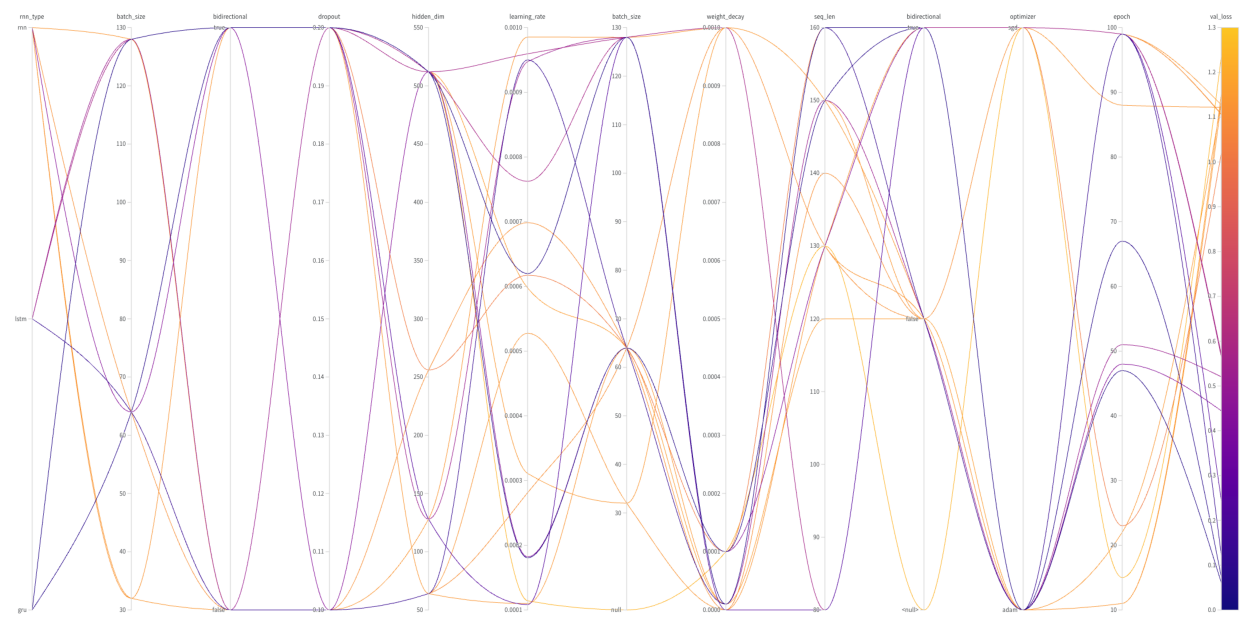

In [6]:
from PIL import Image
import matplotlib.pyplot as plt

img = Image.open('imagenes/val_loss.png')
plt.figure(figsize=(16, 8))  # Hacer la imagen más grande
plt.imshow(img)
plt.axis('off')
plt.show()

### Accuracy
En la evaluación de la Accuracy no se registran cambios en las observaciones del gráfico anterior. 

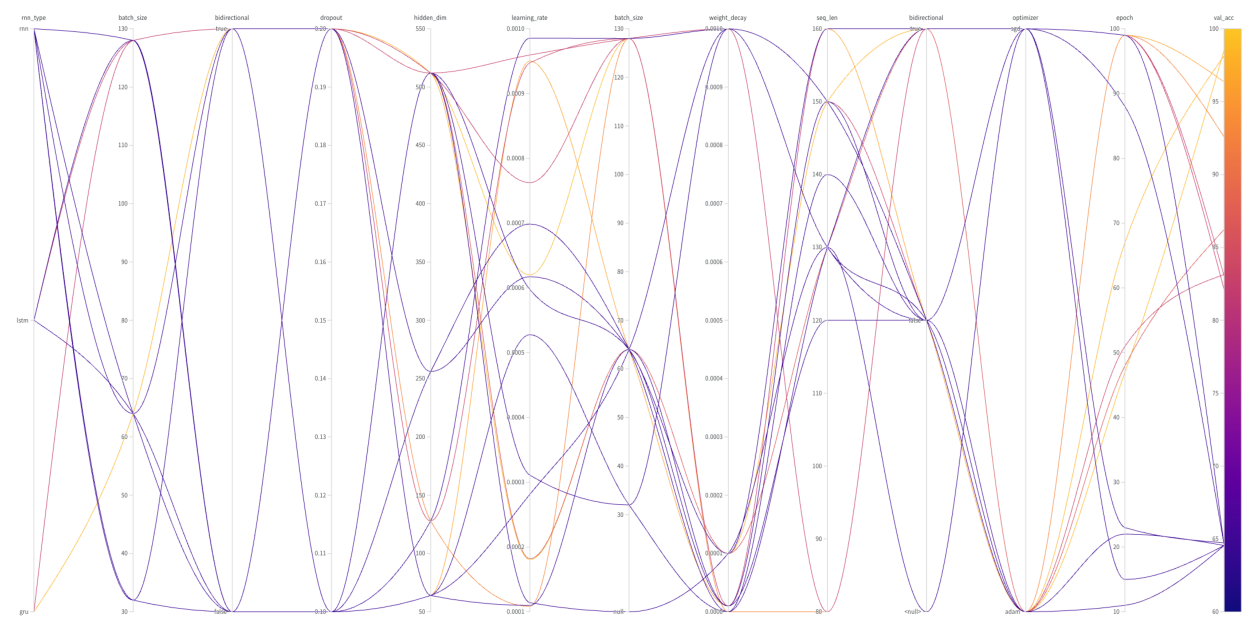

In [7]:
img = Image.open('imagenes/val_acc.png')
plt.figure(figsize=(16, 8))  # Hacer la imagen más grande
plt.imshow(img)
plt.axis('off')
plt.show()

### Recall
En el caso del Recall también se mantienen los puntos ya mencionados en los gráficos anteriores en cuanto a la arquitectura bidireccional, longitud de secuencia y Adam como optimizador, y a esto puede sumarse que un batch size de 64-128 puede colaborar a mejorar esta métrica. 

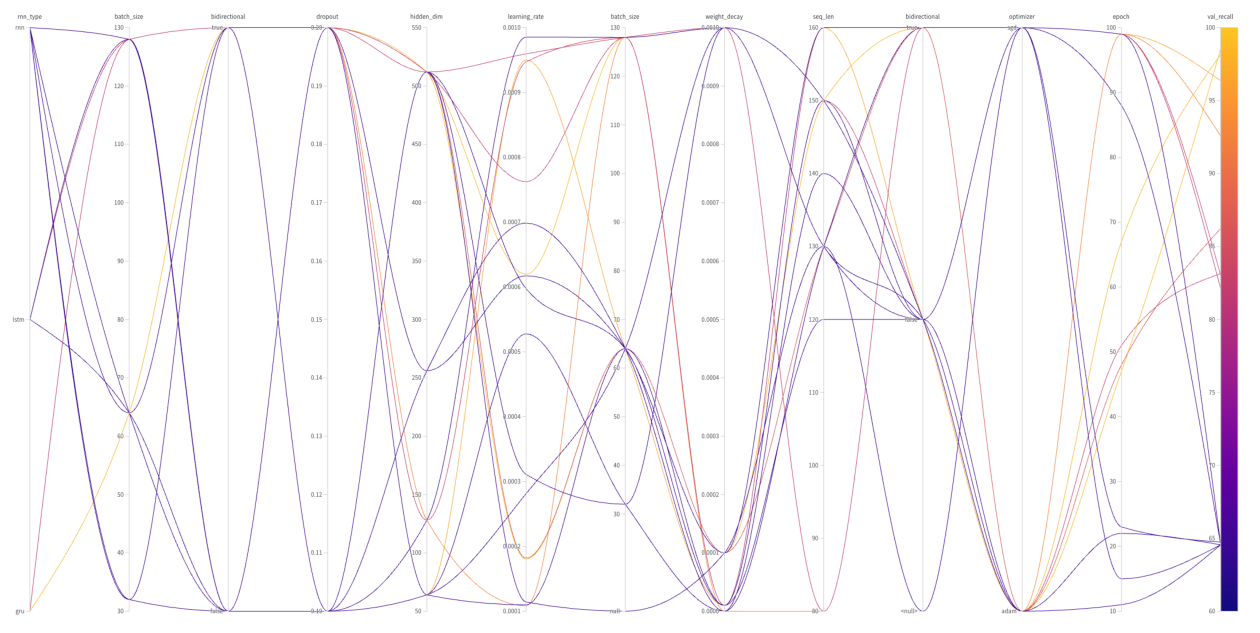

In [8]:
img = Image.open('imagenes/val_recall.png')
plt.figure(figsize=(16, 8))  # Hacer la imagen más grande
plt.imshow(img)
plt.axis('off')
plt.show()

### Precision

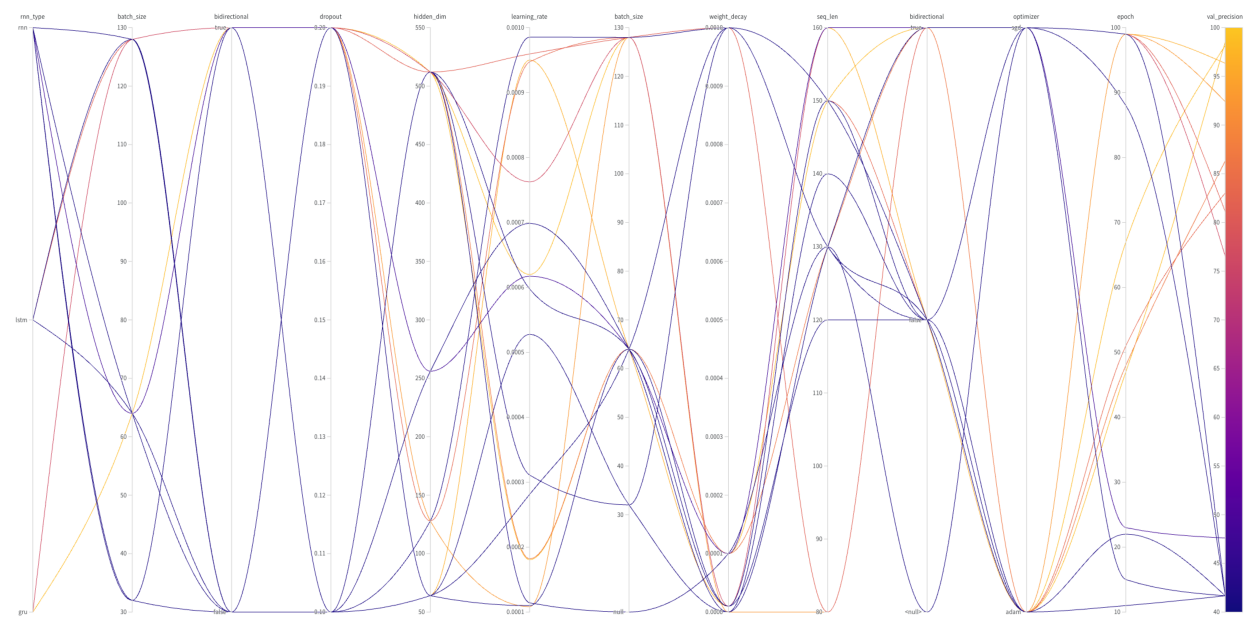

In [ ]:
img = Image.open('imagenes/val_precision.png')
plt.figure(figsize=(16, 8))  
plt.imshow(img)
plt.axis('off')
plt.show()

### F1-score

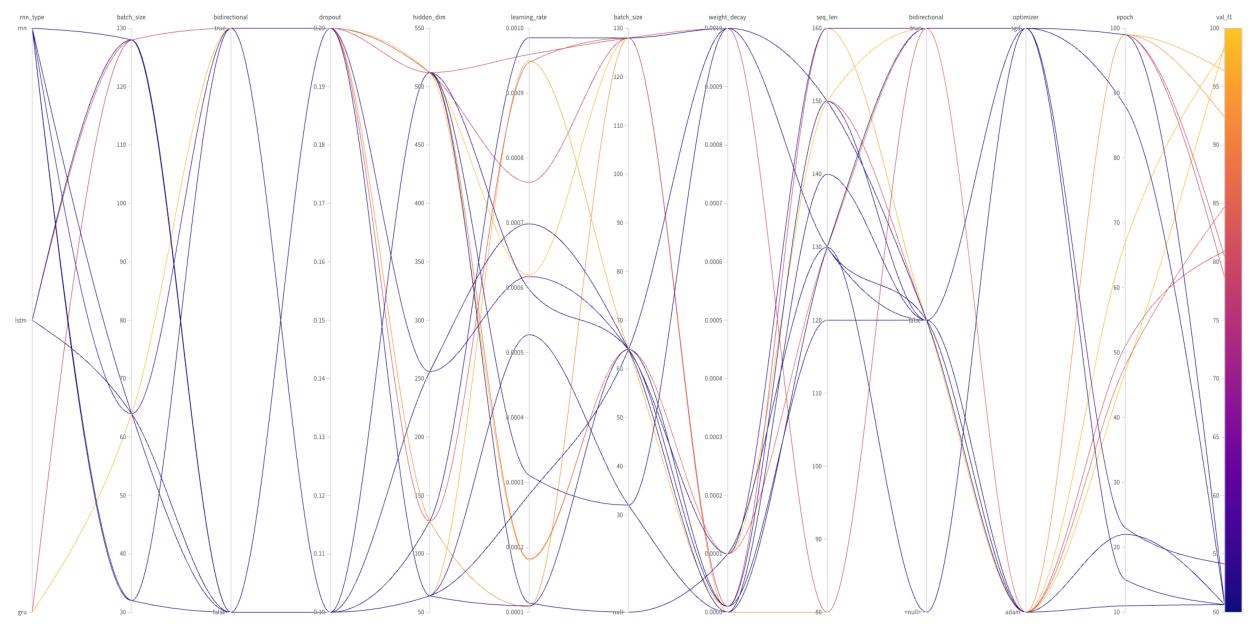

In [10]:
img = Image.open('imagenes/val_f1.png')
plt.figure(figsize=(16, 8))  
plt.imshow(img)
plt.axis('off')
plt.show()

En lineas generales, las combinaciones con Adam, bidirectional=True, secuencias largas y hidden_dim medio–alto son “ganadoras” simultáneamente en val_loss (y el resto de las métricas). 

Además, aumentar mucho el hidden_dim y un dropout alto (0.2) no ayudó a mejorar los resultados de los entrenamientos. 

El early stopping ayudo a reducir la cantidad de epochs de entrenamiento a valores entre 60-80, lo que parecería mostrar un sobre-entrenamiento y empeoramiento de nuestras métricas guía.

GRU fue el mejor modelo alcanzando las menores val_losses, seguido por LSTM y finalmente RNN.